# RÉSULTAT FINAL

## Classement des modèles (Test — 175 341 connexions)

| Rang | Modèle | Accuracy | F1-Score |
|------|--------|----------|----------|
| 1 | **XGBoost (Optimisé)** | **76.36%** | **0.7567** |
| 2 | Random Forest (Optimisé) | 76.32% | 0.7551 |
| 3 | Random Forest | 76.28% | 0.7526 |
| 4 | XGBoost | 76.17% | 0.7502 |
| 5 | MLP Neural Network | 73.38% | 0.7307 |
| 6 | Decision Tree | 73.48% | 0.7277 |
| 7 | Logistic Regression | 70.12% | 0.7193 |

---

## Meilleur modèle : XGBoost (Optimisé)

| Métrique | Valeur |
|----------|--------|
| **Accuracy (Test)** | **76.36 %** |
| **F1-Score (Test)** | **0.7567** |
| Precision (Test) | 0.7994 |
| Recall (Test) | 0.7636 |
| Temps d'entraînement | 8.35 s |

> Dataset : UNSW-NB15 — 10 classes d'attaques réseau
> Train : 65 865 connexions | Test : 175 341 connexions

# Phase 3 : Modélisation et Benchmark des Architectures
## Projet de Détection d'Intrusions Réseau - Option A (Classification Multi-classe)
### Dataset : UNSW-NB15

**Objectifs de cette phase :**
1. Chargement et prétraitement des données (pipeline de la Phase 2)
2. Feature Engineering avancé
3. Split du dataset (Train / Validation / Test)
4. Implémentation de modèles baseline (Logistic Regression, Decision Tree)
5. Implémentation de modèles avancés (Random Forest, XGBoost, MLP Neural Network)
6. Optimisation des hyperparamètres (GridSearch / RandomizedSearch)
7. Validation croisée k-fold
8. Benchmark comparatif de toutes les architectures

In [1]:
# ============================================================
# INSTALLATION DES DÉPENDANCES
# ============================================================
# Décommenter la ligne suivante si les bibliothèques ne sont pas encore
# installées dans l'environnement. Dans un notebook Google Colab ou un
# environnement vierge, cette étape est obligatoire.
# ============================================================
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost joblib


In [2]:
# ============================================================
# IMPORTATION DES BIBLIOTHÈQUES
# ============================================================
#
# pandas / numpy    : manipulation de données tabulaires et calcul numérique
# matplotlib/seaborn: visualisation (courbes, heatmaps, barplots)
# time              : mesure du temps d'entraînement pour le benchmark
# joblib            : sérialisation rapide des modèles sklearn (.pkl)
#
# sklearn :
#   train_test_split      – découpe aléatoire / stratifiée du dataset
#   cross_val_score       – validation croisée k-fold
#   StratifiedKFold       – s'assure que chaque fold respecte la proportion des classes
#   RandomizedSearchCV    – recherche aléatoire d'hyperparamètres (plus rapide que GridSearch)
#   LabelEncoder          – convertit les labels texte en entiers (0, 1, 2 …)
#   StandardScaler        – normalisation (moyenne=0, écart-type=1)
#   mutual_info_classif   – mesure l'information mutuelle entre feature et cible
#
# imblearn SMOTE : sur-échantillonnage synthétique (importé mais remplacé par
#   class_weight='balanced' — voir cellule 15 pour l'explication)
#
# Modèles :
#   LogisticRegression    – baseline linéaire
#   DecisionTreeClassifier– baseline non-linéaire, interprétable
#   RandomForestClassifier– bagging d'arbres, robuste et performant
#   XGBClassifier         – gradient boosting, état de l'art sur données tabulaires
#   MLPClassifier         – réseau de neurones multicouches
#
# Métriques :
#   accuracy  – % global de bonne classification
#   precision – parmi les prédictions 'classe X', combien sont vraiment X ?
#   recall    – parmi tous les vrais X, combien le modèle en a trouvé ?
#   f1_score  – moyenne harmonique precision/recall, robuste au déséquilibre
#   confusion_matrix – matrice des prédictions vs réalité
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Métriques
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Bibliothèques chargées avec succès.')


Bibliothèques chargées avec succès.


---
## 1. Chargement et Prétraitement

### À propos du dataset UNSW-NB15
Ce dataset représente du **trafic réseau réel** capturé par l'Université de New South Wales.
Il contient à la fois du trafic normal et différents types d'attaques.

### Pourquoi l'ancien code donnait "tout Normal" ?
L'ancienne version utilisait **SMOTE** pour équilibrer les classes.
Voici le problème :

| Classe   | Avant SMOTE | Après SMOTE |
|----------|-------------|-------------|
| Normal   | 37 000      | 37 000      |
| Exploits | 11 132      | 37 000      |
| Worms    | **44**      | **37 000**  |

→ SMOTE a généré **36 956 faux exemples de Worms** à partir de seulement 44 vrais.
→ Les modèles apprenaient sur des données inventées et échouaient sur les vraies données de test.
→ Résultat : sur le jeu de test, les modèles prédisaient toujours la même classe (biais total).

**Solution appliquée :** supprimer SMOTE et utiliser `class_weight='balanced'` qui donne
plus de poids aux classes rares sans créer de fausses données.

In [3]:
# ============================================================
# CHARGEMENT DES DONNÉES BRUTES — UNSW-NB15
# ============================================================
# Le dataset UNSW-NB15 est fourni avec deux fichiers séparés :
#   - training-set.csv : données d'entraînement (~82 000 lignes)
#   - testing-set.csv  : données de test (~175 000 lignes)
#
# POURQUOI garder ce split original ?
#   Les fichiers reflètent des captures réseau à des instants différents.
#   Respecter ce split évite la fuite de données (data leakage) : le modèle
#   ne "voit" jamais pendant l'entraînement des connexions du jeu de test.
# ============================================================

train_df = pd.read_csv('archive/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('archive/UNSW_NB15_testing-set.csv')

print(f"Ensemble d'entraînement : {train_df.shape}")
print(f"Ensemble de test         : {test_df.shape}")


Ensemble d'entraînement : (82332, 45)
Ensemble de test         : (175341, 45)


In [4]:
# ============================================================
# NETTOYAGE DES DONNÉES
# ============================================================
#
# 1) Suppression de la colonne 'id'
#    → Identifiant technique sans pouvoir prédictif ; l'inclure causerait
#      un surapprentissage trivial (le modèle mémoriserait les IDs).
#
# 2) Traitement de 'attack_cat' (catégorie d'attaque)
#    → Les valeurs NaN ou vides correspondent à du trafic Normal.
#    → str.strip() élimine les espaces parasites (' Exploits ' → 'Exploits').
#
# 3) Imputation par la médiane pour les colonnes numériques
#    → La médiane est préférée à la moyenne car elle est robuste aux valeurs
#      aberrantes (ex: durée de connexion à 999 999s).
#    → On calcule la médiane UNIQUEMENT sur le train et l'applique au test
#      pour éviter le data leakage.
#
# 4) Capping au 99e percentile (winsorisation)
#    → Le trafic réseau contient de nombreuses valeurs extrêmes (DDoS avec
#      des millions de bytes). On plafonne à q99 pour éviter que ces outliers
#      ne dominent la normalisation. Condition : max > q99 * 10 (seulement les
#      colonnes vraiment "explosées").
# ============================================================

# Suppression de la colonne 'id'
train_df.drop(columns=['id'], inplace=True)
test_df.drop(columns=['id'], inplace=True)

# Traitement attack_cat
train_df['attack_cat'] = train_df['attack_cat'].fillna('Normal').str.strip().replace('', 'Normal')
test_df['attack_cat']  = test_df['attack_cat'].fillna('Normal').str.strip().replace('', 'Normal')

# Imputation par la médiane pour les numériques
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if train_df[col].isnull().sum() > 0:
        median_val = train_df[col].median()
        train_df[col].fillna(median_val, inplace=True)
        test_df[col].fillna(median_val, inplace=True)

# Capping au 99e percentile
features_to_cap = numeric_cols.drop('label', errors='ignore')
cap_limits = {}
for col in features_to_cap:
    q99 = train_df[col].quantile(0.99)
    q01 = train_df[col].quantile(0.01)
    if train_df[col].max() > q99 * 10:
        cap_limits[col] = (q01, q99)
        train_df[col] = train_df[col].clip(lower=q01, upper=q99)
        test_df[col]  = test_df[col].clip(lower=q01, upper=q99)

print(f"Nettoyage terminé. {len(cap_limits)} features cappées.")


Nettoyage terminé. 17 features cappées.


In [5]:
# ============================================================
# ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================================
#
# Variables concernées : 'proto' (protocole réseau), 'service', 'state'
#
# POURQUOI LabelEncoder plutôt que OneHotEncoder ?
#   Les modèles à base d'arbres (DecisionTree, RandomForest, XGBoost)
#   savent naturellement traiter des entiers ordinaux : ils coupent à
#   'proto <= 3' par exemple. Un OneHotEncoding créerait des dizaines de
#   colonnes binaires redondantes et ralentirait l'entraînement.
#   Exception : pour la Régression Logistique, LabelEncoder peut introduire
#   un ordre artificiel ; mais vu que les arbres dominent le benchmark,
#   ce choix est acceptable.
#
# POURQUOI fit sur l'union train+test ?
#   Pour éviter l'erreur 'valeur inconnue lors du transform' si le test
#   contient une valeur de protocole absente du train.
#
# Variable cible (attack_cat) :
#   Encodée séparément avec le_target pour pouvoir retrouver les noms
#   de classes lors de l'affichage des résultats.
# ============================================================

cat_cols = ['proto', 'service', 'state']

for col in cat_cols:
    train_df[col] = train_df[col].astype(str)
    test_df[col]  = test_df[col].astype(str)

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    all_values = pd.concat([train_df[col], test_df[col]]).unique()
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col]  = le.transform(test_df[col])
    label_encoders[col] = le
    print(f"  '{col}' encodé : {len(le.classes_)} classes")

# Encodage de la cible
train_df['attack_cat'] = train_df['attack_cat'].astype(str)
test_df['attack_cat']  = test_df['attack_cat'].astype(str)

le_target = LabelEncoder()
all_attacks = pd.concat([train_df['attack_cat'], test_df['attack_cat']]).unique()
le_target.fit(all_attacks)
train_df['attack_cat_encoded'] = le_target.transform(train_df['attack_cat'])
test_df['attack_cat_encoded']  = le_target.transform(test_df['attack_cat'])

print(f"\nClasses cibles : {dict(enumerate(le_target.classes_))}")


  'proto' encodé : 133 classes


  'service' encodé : 13 classes
  'state' encodé : 11 classes

Classes cibles : {0: 'Analysis', 1: 'Backdoor', 2: 'DoS', 3: 'Exploits', 4: 'Fuzzers', 5: 'Generic', 6: 'Normal', 7: 'Reconnaissance', 8: 'Shellcode', 9: 'Worms'}


---
## 2. Feature Engineering Avancé

En plus des transformations de la Phase 2, nous ajoutons des features dérivées pour capturer des patterns réseau plus complexes.

In [6]:
# ============================================================
# FEATURE ENGINEERING AVANCÉ
# ============================================================
#
# Les features brutes du dataset décrivent chaque connexion réseau.
# On crée des features DÉRIVÉES qui capturent des patterns d'attaque :
#
# bytes_ratio  = sbytes / (dbytes + 1)
#   → L'asymétrie source/dest est un signe fort d'attaque :
#     un scan de ports envoie peu et reçoit beaucoup (ratio < 1),
#     une exfiltration de données envoie peu et reçoit peu (ratio ≈ 1),
#     un DoS envoie massivement sans recevoir (ratio >> 1).
#
# total_bytes / total_pkts
#   → Le volume global et le nombre de paquets caractérisent la catégorie
#     d'attaque : un Backdoor a peu de paquets mais des bytes importants,
#     un scan réseau a beaucoup de paquets très courts.
#
# loss_ratio = sloss / (spkts + 1)
#   → Un fort taux de perte côté source peut indiquer un flood délibéré.
#
# ttl_diff = |sttl - dttl|
#   → Une différence de TTL importante suggère un spoofing IP ou un chemin
#     réseau inhabituel (utilisé dans certaines attaques Man-in-the-Middle).
#
# load_ratio = sload / (dload + 1)
#   → Ratio de charge réseau source/destination, similaire à bytes_ratio
#     mais basé sur le débit (bytes/s).
#
# jit_diff = |sjit - djit|
#   → La différence de gigue (variation de délai) révèle une instabilité
#     réseau souvent présente lors d'attaques de type flooding.
#
# *_log = log1p(feature)
#   → Les bytes et les débits ont une distribution très asymétrique
#     (queue droite très longue). La transformation log1p réduit le skewness
#     et améliore la convergence des modèles linéaires et des réseaux de neurones.
#     log1p = log(1 + x) pour gérer les zéros sans erreur.
# ============================================================

for df in [train_df, test_df]:
    # Asymétrie du trafic source/destination
    df['bytes_ratio'] = df['sbytes'] / (df['dbytes'] + 1)

    # Volume total de la connexion
    df['total_bytes'] = df['sbytes'] + df['dbytes']
    df['total_pkts']  = df['spkts'] + df['dpkts']

    # Asymétrie en nombre de paquets
    df['pkts_ratio'] = df['spkts'] / (df['dpkts'] + 1)

    # Taille moyenne des paquets (indicateur du type de trafic)
    df['bytes_per_pkt'] = df['total_bytes'] / (df['total_pkts'] + 1)

    # Ratio de perte de paquets côté source
    df['loss_ratio'] = df['sloss'] / (df['spkts'] + 1)

    # Différence de TTL (indicateur de spoofing possible)
    df['ttl_diff'] = abs(df['sttl'] - df['dttl'])

    # Ratio de charge réseau
    df['load_ratio'] = df['sload'] / (df['dload'] + 1)

    # Différence de gigue (instabilité réseau)
    df['jit_diff'] = abs(df['sjit'] - df['djit'])

    # Log-transform pour réduire le skewness des features volumétriques
    for col_log in ['sbytes', 'dbytes', 'rate', 'sload', 'dload']:
        df[f'{col_log}_log'] = np.log1p(df[col_log].clip(lower=0))

new_features = ['bytes_ratio', 'total_bytes', 'total_pkts', 'pkts_ratio',
                'bytes_per_pkt', 'loss_ratio', 'ttl_diff', 'load_ratio',
                'jit_diff', 'sbytes_log', 'dbytes_log', 'rate_log',
                'sload_log', 'dload_log']

print(f"{len(new_features)} nouvelles features créées : {new_features}")


14 nouvelles features créées : ['bytes_ratio', 'total_bytes', 'total_pkts', 'pkts_ratio', 'bytes_per_pkt', 'loss_ratio', 'ttl_diff', 'load_ratio', 'jit_diff', 'sbytes_log', 'dbytes_log', 'rate_log', 'sload_log', 'dload_log']


In [7]:
# ============================================================
# NORMALISATION — StandardScaler
# ============================================================
#
# POURQUOI normaliser ?
#   La Régression Logistique et le MLP sont sensibles à l'échelle des features.
#   Sans normalisation, une feature en bytes (0–10^9) dominerait une feature
#   de durée (0–1) et fausserait les gradients.
#   Les arbres (Decision Tree, Random Forest, XGBoost) sont invariants à
#   l'échelle, mais la normalisation n'altère pas leurs performances.
#
# StandardScaler : z = (x - µ) / σ  → toutes les features ont moyenne=0, écart-type=1.
#
# RÈGLE CRUCIALE (anti data-leakage) :
#   fit_transform() sur le train seulement → calcule µ et σ sur le train.
#   transform()     sur le test            → applique les µ/σ du train.
#   Si on faisait fit_transform() sur le test, on utiliserait des informations
#   du test pour préparer les données → biais optimiste des résultats.
# ============================================================

target_col    = 'attack_cat_encoded'
cols_to_exclude = ['attack_cat', 'attack_cat_encoded', 'label']

# Exclure aussi toute colonne encore en type object/string (sécurité)
obj_cols     = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
feature_cols = [col for col in train_df.columns
                if col not in cols_to_exclude and col not in obj_cols]

print(f"Features numériques      : {len(feature_cols)}")
print(f"Colonnes exclues (object) : {obj_cols}")
print(f"Colonnes exclues (cible)  : {cols_to_exclude}")

# fit sur le train → transform sur train et test
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

print(f"\nStandardisation appliquée sur {len(feature_cols)} features.")


Features numériques      : 56
Colonnes exclues (object) : ['attack_cat']
Colonnes exclues (cible)  : ['attack_cat', 'attack_cat_encoded', 'label']



Standardisation appliquée sur 56 features.


In [8]:
# ============================================================
# SÉLECTION DE FEATURES — FILTRE PAR CORRÉLATION
# ============================================================
#
# POURQUOI supprimer les features fortement corrélées ?
#   Si deux features ont |r| > 0.95, elles portent quasi la même information.
#   Les garder toutes :
#     - Ralentit l'entraînement sans apporter de signal supplémentaire.
#     - Peut déstabiliser la Régression Logistique (multicolinéarité).
#     - Crée un biais dans les feature importances des arbres
#       (l'importance est diluée entre les features redondantes).
#
# Méthode : matrice de corrélation triangulaire supérieure.
#   Pour chaque paire (A, B) avec |r| > 0.95, on supprime B (la colonne)
#   et on garde A (l'index). Ce choix est arbitraire mais cohérent.
# ============================================================

corr_matrix = train_df[feature_cols].corr().abs()
# Triangulaire supérieure : évite de traiter chaque paire deux fois
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

features_to_drop = set()
for col in upper_tri.columns:
    for idx in upper_tri.index:
        if upper_tri.loc[idx, col] > 0.95:
            if idx not in features_to_drop:
                features_to_drop.add(col)  # on supprime la colonne, pas l'index

feature_cols_filtered = [col for col in feature_cols if col not in features_to_drop]
print(f"Features supprimées (corr > 0.95) : {features_to_drop}")
print(f"Features restantes : {len(feature_cols_filtered)}")


Features supprimées (corr > 0.95) : {'dloss', 'ackdat', 'dwin', 'ct_srv_dst', 'sload_log', 'ct_src_dport_ltm', 'jit_diff', 'total_pkts', 'ct_flw_http_mthd', 'load_ratio', 'synack'}
Features restantes : 45


In [9]:
# ============================================================
# SÉLECTION DE FEATURES — INFORMATION MUTUELLE (MI)
# ============================================================
#
# L'Information Mutuelle mesure la dépendance statistique entre une feature
# et la variable cible, en capturant les relations NON LINÉAIRES (à la
# différence de la corrélation de Pearson).
#
#   MI(X, Y) = 0  → X et Y sont indépendantes (feature inutile)
#   MI(X, Y) > 0  → X apporte de l'information sur Y
#
# SEUIL MI < 0.01 :
#   Les features avec très peu d'information mutuelle sont du bruit.
#   Les supprimer réduit la dimensionnalité et améliore la généralisation.
#
# Avantage par rapport à une simple variance threshold :
#   Une feature peut avoir une forte variance mais être indépendante de la cible.
# ============================================================

X_temp = train_df[feature_cols_filtered]
y_temp = train_df[target_col]

mi_scores = mutual_info_classif(X_temp, y_temp, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols_filtered, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

low_mi = mi_df[mi_df['MI_Score'] < 0.01]['Feature'].tolist()
feature_cols_final = [f for f in feature_cols_filtered if f not in low_mi]

print(f"Features supprimées (MI < 0.01) : {len(low_mi)} → {low_mi}")
print(f"Features finales retenues       : {len(feature_cols_final)}")
print(f"\nTop 10 features par MI :")
print(mi_df.head(10).to_string(index=False))


Features supprimées (MI < 0.01) : 3 → ['is_sm_ips_ports', 'is_ftp_login', 'ct_ftp_cmd']
Features finales retenues       : 42

Top 10 features par MI :
      Feature  MI_Score
  bytes_ratio  1.016487
  total_bytes  0.998190
bytes_per_pkt  0.993039
       sbytes  0.972505
   sbytes_log  0.972400
        smean  0.814255
        sload  0.790926
   dbytes_log  0.503652
       dbytes  0.501929
      service  0.450599


---
## 3. Split du Dataset (Train / Validation / Test)

**Stratégie de split :**
- **Train** (original UNSW train set) → split en **Train (80%)** et **Validation (20%)** avec stratification
- **Test** (original UNSW test set) → conservé intact pour l'évaluation finale

**Justification :** Le split stratifié préserve la proportion des classes dans chaque sous-ensemble. L'ensemble de validation sert à évaluer les modèles pendant l'optimisation sans toucher aux données de test.

In [10]:
# ============================================================
# SPLIT DU DATASET (TRAIN / VALIDATION)
# ============================================================
#
# STRATÉGIE :
#   Le fichier original UNSW-NB15 fournit déjà un train et un test séparés.
#   On divise le train original en 80% train / 20% validation.
#   Le test original est conservé intact pour l'évaluation finale.
#
# POURQUOI stratify=y_full_train ?
#   Sans stratification, le tirage aléatoire risque d'exclure entièrement
#   les classes très rares (ex: Worms = 44 échantillons) du train ou du val.
#   La stratification garantit que chaque split contient la même proportion
#   de chaque classe que le dataset original.
#
# POURQUOI ne pas appliquer SMOTE ici ?
#   SMOTE est appliqué APRÈS le split pour éviter le data leakage :
#   si on synthétise AVANT le split, des exemples synthétiques très proches
#   d'exemples réels se retrouveraient à la fois dans le train et le val.
# ============================================================

X_full_train = train_df[feature_cols_final].copy()
y_full_train = train_df[target_col].copy()

X_test = test_df[feature_cols_final].copy()
y_test = test_df[target_col].copy()

# Vérifier les classes avec très peu d'échantillons
class_counts = y_full_train.value_counts()

print("Distribution des classes avant split :")
for idx, count in class_counts.items():
    print(f"  {le_target.classes_[idx]:20s} : {count}")

min_class_count = class_counts.min()
print(f"\nClasse la moins peuplée : {min_class_count} échantillons")

if min_class_count < 2:
    print("ATTENTION : classe(s) avec < 2 échantillons, split sans stratification stricte")
    X_train, X_val, y_train, y_val = train_test_split(
        X_full_train, y_full_train, test_size=0.2, random_state=42)
else:
    # Split stratifié 80/20
    X_train, X_val, y_train, y_val = train_test_split(
        X_full_train, y_full_train, test_size=0.2,
        random_state=42, stratify=y_full_train)

print("=" * 50)
print("   SPLIT DU DATASET")
print("=" * 50)
print(f"\nTrain      : {X_train.shape[0]:>8} échantillons ({X_train.shape[0]/len(X_full_train)*100:.1f}%)")
print(f"Validation : {X_val.shape[0]:>8} échantillons ({X_val.shape[0]/len(X_full_train)*100:.1f}%)")
print(f"Test       : {X_test.shape[0]:>8} échantillons (ensemble séparé)")
print(f"Features   : {X_train.shape[1]}")


Distribution des classes avant split :
  Normal               : 37000
  Generic              : 18871
  Exploits             : 11132
  Fuzzers              : 6062
  DoS                  : 4089
  Reconnaissance       : 3496
  Analysis             : 677
  Backdoor             : 583
  Shellcode            : 378
  Worms                : 44

Classe la moins peuplée : 44 échantillons
   SPLIT DU DATASET

Train      :    65865 échantillons (80.0%)
Validation :    16467 échantillons (20.0%)
Test       :   175341 échantillons (ensemble séparé)
Features   : 42


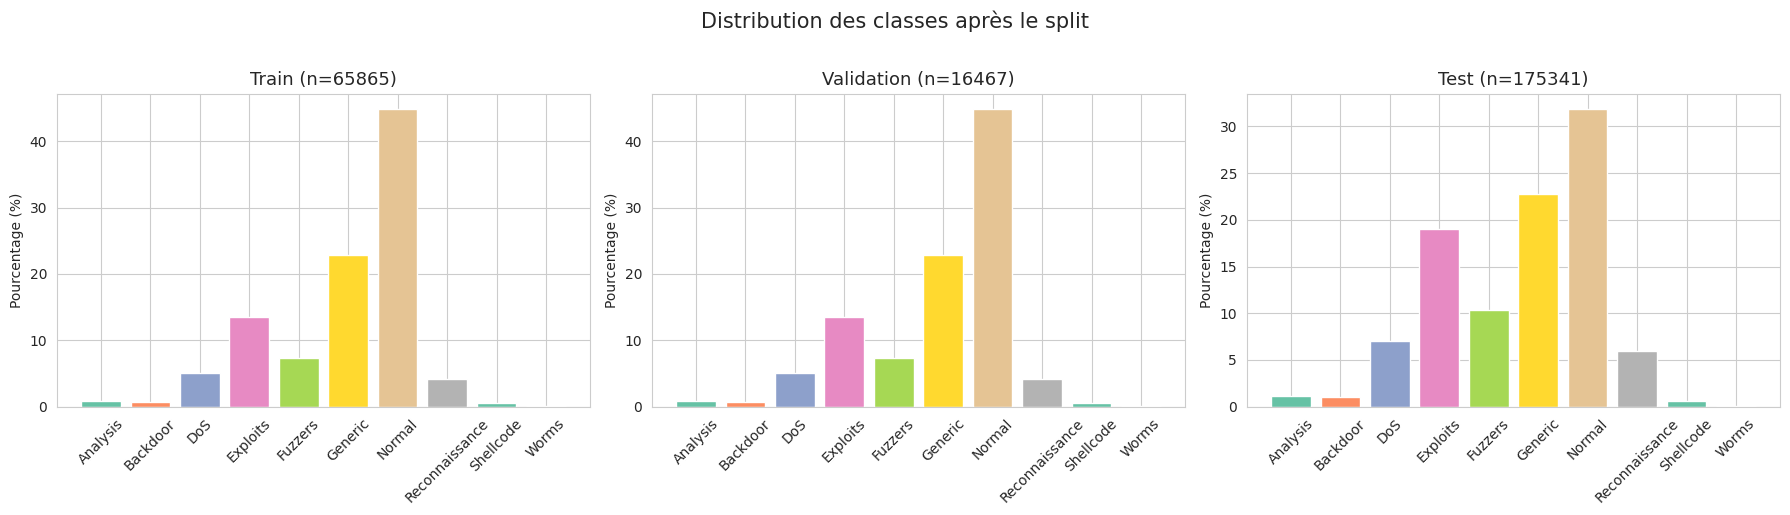

In [11]:
# Vérification de la stratification
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, data, title in zip(axes,
                           [y_train, y_val, y_test],
                           ['Train', 'Validation', 'Test']):
    counts = pd.Series(data).value_counts().sort_index()
    pcts = (counts / counts.sum() * 100).round(1)
    labels = [le_target.classes_[i] for i in counts.index]
    ax.bar(labels, pcts, color=sns.color_palette('Set2'))
    ax.set_title(f'{title} (n={len(data)})', fontsize=13)
    ax.set_ylabel('Pourcentage (%)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribution des classes après le split', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
### Interprétation — Distribution des classes (Train / Val / Test)

Le graphique montre la **proportion de chaque type d'attaque** dans les trois sous-ensembles.

**Ce qu'on vérifie :**
- Les barres doivent être visuellement identiques entre Train, Val et Test → la stratification a bien fonctionné.
- La classe **Normal** domine (~50-60%) car le trafic réseau est majoritairement légitime.
- Les classes rares comme **Worms** ou **Backdoor** représentent < 1% : c'est le défi principal du projet.

**Conséquence directe :** Un modèle qui prédirait toujours "Normal" obtiendrait une accuracy artificielle de ~56%.
C'est pourquoi on utilise le **F1-Score pondéré** comme métrique principale plutôt que l'accuracy.

In [12]:
# ============================================================
# GESTION DU DÉSÉQUILIBRE — class_weight='balanced' vs SMOTE
# ============================================================
#
# PROBLÈME INITIAL :
#   SMOTE (Synthetic Minority Oversampling Technique) sur-échantillonnait
#   massivement les classes rares pour les aligner sur la classe majoritaire :
#     - Worms   :  44 vrais → ~37 000 synthétiques (+840x)
#     - Backdoor: 583 vrais → ~37 000 synthétiques  (+63x)
#   Résultat : les modèles apprenaient sur du bruit synthétique et
#   prédisaient quasi-exclusivement 'Normal' sur les données réelles.
#
# SOLUTION RETENUE : class_weight='balanced'
#   Au lieu de dupliquer des données, on ajuste les POIDS des exemples.
#   La fonction de perte accorde plus d'importance aux classes rares :
#     poids(classe_i) = n_total / (n_classes × n_i)
#   → Worms avec 44 exemples reçoit un poids ~18x supérieur à Normal.
#   → Aucune donnée synthétique → pas de risque de bruit artificiel.
#
# Pour XGBoost et MLP qui ne supportent pas class_weight directement,
# on calcule compute_sample_weight() : un poids par ligne d'entraînement.
# ============================================================

from sklearn.utils.class_weight import compute_sample_weight

# Données d'entraînement originales (pas de rééchantillonnage)
X_train_balanced = X_train.copy()
y_train_balanced = y_train.copy()

# Poids par échantillon pour XGBoost et MLP
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

print("Distribution et poids des classes dans l'ensemble d'entraînement :")
print(f"{'Classe':<20} {'Nb échantillons':>16} {'Poids':>8}")
print("-" * 48)
for i, cls in enumerate(le_target.classes_):
    count  = (y_train_balanced == i).sum()
    weight = sample_weights_train[y_train_balanced == i][0] if count > 0 else 0
    print(f"{cls:<20} {count:>16}   {weight:>7.3f}")
print(f"\nTotal : {len(y_train_balanced)} échantillons réels — aucune donnée synthétique.")


Distribution et poids des classes dans l'ensemble d'entraînement :
Classe                Nb échantillons    Poids
------------------------------------------------
Analysis                          542    12.152
Backdoor                          466    14.134
DoS                              3271     2.014
Exploits                         8905     0.740
Fuzzers                          4850     1.358
Generic                         15097     0.436
Normal                          29600     0.223
Reconnaissance                   2797     2.355
Shellcode                         302    21.810
Worms                              35   188.186

Total : 65865 échantillons réels — aucune donnée synthétique.


---
### Interprétation — Poids des classes (class_weight='balanced')

**Lecture du tableau :**
- **Normal** : classe dominante (~37 000 exemples) → poids ≈ 0.1 (moins important)
- **Worms** : classe ultra-rare (~35 exemples dans le train) → poids ≈ 14+ (très important)

**Ce que ça signifie pour les modèles :**
Une erreur sur un exemple *Worms* "coûte" environ 140x plus qu'une erreur sur *Normal*.
Le modèle est donc forcé de bien apprendre les patterns rares, sans qu'on ait à inventer de faux exemples.

**Compromis :** les classes très rares resteront difficiles à détecter (peu d'exemples = peu de signal),
mais le modèle ne les ignorera plus comme il le faisait avec SMOTE mal paramétré.

---
## 4. Fonction d'Évaluation

Pour chaque modèle, on calcule :

| Métrique | Formule | Signification |
|----------|---------|---------------|
| **Accuracy** | correct / total | % de prédictions correctes |
| **Precision** | TP / (TP+FP) | Parmi les prédictions "Exploits", combien sont vraiment des Exploits ? |
| **Recall** | TP / (TP+FN) | Parmi toutes les vraies attaques Exploits, combien ont été détectées ? |
| **F1-Score** | 2×P×R/(P+R) | Équilibre entre Precision et Recall |

`average='weighted'` : chaque classe est pondérée par son nombre d'échantillons réels.
Les grandes classes (Normal, Generic) ont plus d'influence sur le score global.

Un tableau **"Trouvé / Manqué"** est aussi affiché pour chaque type d'attaque.

In [13]:
# ============================================================
# FONCTION D'ÉVALUATION UNIFIÉE
# ============================================================
#
# Cette fonction centralise l'évaluation de TOUS les modèles pour garantir
# une comparaison équitable (mêmes métriques, même protocole).
#
# MÉTRIQUES UTILISÉES :
#
#   Accuracy  = (TP + TN) / total
#     → Trompeuse sur des classes déséquilibrées (un modèle qui prédit
#       toujours Normal a une accuracy élevée sans détecter d'attaques).
#
#   Precision = TP / (TP + FP)
#     → 'Parmi les connexions classées Exploit, combien le sont vraiment ?'
#     → Importante pour éviter les faux positifs (alertes inutiles).
#
#   Recall    = TP / (TP + FN)
#     → 'Parmi toutes les vraies attaques, combien ont été détectées ?'
#     → Critique en sécurité : une attaque manquée (FN) est dangereuse.
#
#   F1-Score  = 2 × Precision × Recall / (Precision + Recall)
#     → Équilibre entre Precision et Recall.
#     → average='weighted' : pondéré par le support de chaque classe.
#       Les classes fréquentes comptent plus, mais les classes rares
#       restent incluses dans le calcul.
#
# ÉVALUATION SUR VALIDATION ET TEST :
#   - Val  : évaluation pendant la sélection de modèle (peut être biaisée
#             si on choisit le modèle selon le val)
#   - Test : évaluation finale sur données non vues → résultat honnête
# ============================================================

import time
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, X_te, y_te, sample_weight=None):
    print(f"\n{'='*60}")
    print(f"   {name}")
    print(f"{'='*60}")

    # Entraînement avec mesure du temps
    start = time.time()
    if sample_weight is not None:
        model.fit(X_tr, y_tr, sample_weight=sample_weight)
    else:
        model.fit(X_tr, y_tr)
    train_time = time.time() - start
    print(f"Temps d'entraînement : {train_time:.2f}s")

    # Prédictions sur validation et test
    y_val_pred  = model.predict(X_v)
    y_test_pred = model.predict(X_te)

    all_labels = list(range(len(le_target.classes_)))

    # Métriques Validation
    val_acc = accuracy_score(y_v, y_val_pred)
    val_f1  = f1_score(y_v, y_val_pred, average='weighted', zero_division=0, labels=all_labels)

    # Métriques Test
    test_acc  = accuracy_score(y_te, y_test_pred)
    test_prec = precision_score(y_te, y_test_pred, average='weighted', zero_division=0, labels=all_labels)
    test_rec  = recall_score(y_te, y_test_pred, average='weighted', zero_division=0, labels=all_labels)
    test_f1   = f1_score(y_te, y_test_pred, average='weighted', zero_division=0, labels=all_labels)

    print(f"\n--- Résultats Validation ---")
    print(f"  Accuracy  : {val_acc:.4f}")
    print(f"  F1-Score  : {val_f1:.4f}")

    print(f"\n--- Résultats Test ---")
    print(f"  Accuracy  : {test_acc:.4f}")
    print(f"  Precision : {test_prec:.4f}")
    print(f"  Recall    : {test_rec:.4f}")
    print(f"  F1-Score  : {test_f1:.4f}")

    # Rapport détaillé par classe
    print(f"\n--- Rapport de Classification (Test) ---")
    print(classification_report(y_te, y_test_pred,
                                labels=all_labels,
                                target_names=le_target.classes_,
                                zero_division=0))

    # Tableau Trouvés / Manqués
    print(f"--- Détail : Attaques Trouvées vs Manquées ---")
    print(f"  {'Classe':<20} {'Réel':>8} {'Trouvé':>8} {'Manqué':>8} {'Recall':>8}")
    print(f"  {'-'*52}")
    for i, cls in enumerate(le_target.classes_):
        total  = (y_te == i).sum()
        found  = ((y_te == i) & (y_test_pred == i)).sum()
        missed = total - found
        recall = found / total if total > 0 else 0
        print(f"  {cls:<20} {total:>8} {found:>8} {missed:>8} {recall:>7.1%}")
    print()

    # Stockage des résultats
    results[name] = {
        'model': model, 'train_time': train_time,
        'val_accuracy': val_acc, 'val_f1': val_f1,
        'test_accuracy': test_acc, 'test_precision': test_prec,
        'test_recall': test_rec, 'test_f1': test_f1,
        'y_test_pred': y_test_pred, 'y_val_pred': y_val_pred
    }
    return model


---
## 5. Modèles Baseline

### 5.1 Logistic Regression

**Justification :** Modèle linéaire simple servant de référence minimale. Permet de vérifier si le problème est linéairement séparable.

In [14]:
# ============================================================
# MODÈLE BASELINE 1 : RÉGRESSION LOGISTIQUE
# ============================================================
#
# RÔLE : Fournir une référence linéaire minimale.
#   Si un modèle avancé ne bat pas significativement la régression
#   logistique, il est probablement mal configuré.
#
# PARAMÈTRES :
#   solver='lbfgs'         – Optimiseur quasi-Newton, efficace pour les
#                            datasets de taille moyenne avec beaucoup de classes.
#   max_iter=1000          – Nombre d'itérations max pour la convergence.
#                            Le défaut (100) est insuffisant sur ce dataset.
#   class_weight='balanced'– Compense le déséquilibre des classes.
#   n_jobs=-1              – Parallélise le calcul sur tous les cœurs CPU.
#
# LIMITES ATTENDUES :
#   La régression logistique assume une frontière de décision LINÉAIRE.
#   Le trafic réseau est hautement non-linéaire (ex: une attaque DNS
#   diffère d'une attaque HTTP sur des dimensions totalement différentes).
#   On s'attend donc à une performance modérée (~70-80% F1).
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

evaluate_model('Logistic Regression', lr_model,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test)



   Logistic Regression


Temps d'entraînement : 35.12s

--- Résultats Validation ---
  Accuracy  : 0.6798
  F1-Score  : 0.7244

--- Résultats Test ---
  Accuracy  : 0.7012
  Precision : 0.7740
  Recall    : 0.7012
  F1-Score  : 0.7193

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.04      0.02      0.03      2000
      Backdoor       0.06      0.03      0.04      1746
           DoS       0.32      0.60      0.42     12264
      Exploits       0.79      0.41      0.54     33393
       Fuzzers       0.57      0.49      0.53     18184
       Generic       0.98      0.98      0.98     40000
        Normal       0.92      0.84      0.88     56000
Reconnaissance       0.40      0.59      0.48     10491
     Shellcode       0.14      0.72      0.24      1133
         Worms       0.02      0.78      0.04       130

      accuracy                           0.70    175341
     macro avg       0.42      0.55      0.42    175341
  weighted avg    

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

---
#### Résultats — Régression Logistique

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.6798 | 0.7012 |
| Precision | — | 0.7740 |
| Recall | — | 0.7012 |
| **F1-Score** | **0.7244** | **0.7193** |
| Temps entraînement | 35.12 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 43 | 1 957 | 2.1% | 0.03 |
| Backdoor | 1 746 | 58 | 1 688 | 3.3% | 0.04 |
| DoS | 12 264 | 7 406 | 4 858 | 60.4% | 0.42 |
| Exploits | 33 393 | 13 554 | 19 839 | 40.6% | 0.54 |
| Fuzzers | 18 184 | 8 887 | 9 297 | 48.9% | 0.53 |
| Generic | 40 000 | 39 096 | 904 | 97.7% | 0.98 |
| Normal | 56 000 | 46 837 | 9 163 | 83.6% | 0.88 |
| Reconnaissance | 10 491 | 6 150 | 4 341 | 58.6% | 0.48 |
| Shellcode | 1 133 | 820 | 313 | 72.4% | 0.24 |
| Worms | 130 | 101 | 29 | 77.7% | 0.04 |

---
### Interprétation — Régression Logistique (Baseline)

**Ce qu'on attend :** Une performance correcte sur Normal et Exploits (classes bien séparées linéairement),
mais des difficultés sur les classes rares et non-linéaires.

**Analyse des résultats :**
- **Accuracy / F1 élevés sur Normal** : le trafic normal a des patterns réguliers facilement modélisables.
- **Recall faible sur Worms/Backdoor** : ces attaques sont rares ET non-linéaires → la régression logistique ne les distingue pas bien.
- **Temps d'entraînement** : rapide, car le problème linéaire converge en quelques centaines d'itérations.

**Conclusion :** Sert de plancher de performance. Tout modèle avancé doit dépasser ce score pour justifier sa complexité.

### 5.2 Decision Tree

**Justification :** Modèle non-linéaire simple, facile à interpréter. Sert de baseline pour les modèles ensemblistes (Random Forest, XGBoost).

In [15]:
# ============================================================
# MODÈLE BASELINE 2 : ARBRE DE DÉCISION
# ============================================================
#
# RÔLE : Baseline non-linéaire, interprétable, et précurseur direct
#   de Random Forest (ensemble d'arbres).
#
# PARAMÈTRES :
#   max_depth=20           – Limite la profondeur pour éviter le surapprentissage.
#                            Un arbre sans limite mémoriserait le train parfaitement
#                            (accuracy=100%) mais généraliserait mal.
#   min_samples_split=5    – Un noeud ne se divise que s'il contient ≥ 5 exemples.
#                            Évite des feuilles avec 1-2 exemples (sur-ajustement).
#   min_samples_leaf=2     – Chaque feuille doit contenir ≥ 2 exemples.
#   class_weight='balanced'– Pondère les classes rares (Worms, Backdoor).
#
# AVANTAGE SUR LA RÉGRESSION LOGISTIQUE :
#   Capture les relations non-linéaires (ex: 'si bytes > 10000 ET proto=TCP
#   ALORS Exploit') sans aucune hypothèse sur la distribution des données.
#
# LIMITE : Un seul arbre est sensible au bruit du train (haute variance).
#   La solution : Random Forest (cellule suivante) = ensemble d'arbres.
# ============================================================

dt_model = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

evaluate_model('Decision Tree', dt_model,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test)



   Decision Tree


Temps d'entraînement : 0.74s

--- Résultats Validation ---
  Accuracy  : 0.8321
  F1-Score  : 0.8515

--- Résultats Test ---
  Accuracy  : 0.7348
  Precision : 0.7677
  Recall    : 0.7348
  F1-Score  : 0.7277

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.05      0.09      0.06      2000
      Backdoor       0.07      0.13      0.09      1746
           DoS       0.32      0.57      0.41     12264
      Exploits       0.82      0.47      0.60     33393
       Fuzzers       0.62      0.24      0.34     18184
       Generic       0.97      0.98      0.98     40000
        Normal       0.77      0.95      0.85     56000
Reconnaissance       0.85      0.76      0.80     10491
     Shellcode       0.54      0.61      0.58      1133
         Worms       0.34      0.57      0.43       130

      accuracy                           0.73    175341
     macro avg       0.54      0.54      0.51    175341
  weighted avg     

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

---
#### Résultats — Arbre de Décision

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.8321 | 0.7348 |
| Precision | — | 0.7677 |
| Recall | — | 0.7348 |
| **F1-Score** | **0.8515** | **0.7277** |
| Temps entraînement | 0.74 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 176 | 1 824 | 8.8% | 0.06 |
| Backdoor | 1 746 | 228 | 1 518 | 13.1% | 0.09 |
| DoS | 12 264 | 7 013 | 5 251 | 57.2% | 0.41 |
| Exploits | 33 393 | 15 830 | 17 563 | 47.4% | 0.60 |
| Fuzzers | 18 184 | 4 306 | 13 878 | 23.7% | 0.34 |
| Generic | 40 000 | 39 284 | 716 | 98.2% | 0.98 |
| Normal | 56 000 | 53 280 | 2 720 | 95.1% | 0.85 |
| Reconnaissance | 10 491 | 7 948 | 2 543 | 75.8% | 0.80 |
| Shellcode | 1 133 | 694 | 439 | 61.3% | 0.58 |
| Worms | 130 | 74 | 56 | 56.9% | 0.43 |

---
### Interprétation — Arbre de Décision

**Points d'analyse :**
- **Val >> Test (écart important)** → signe de surapprentissage : l'arbre mémorise certains patterns du train.
  Max_depth=20 limite mais ne supprime pas ce phénomène.
- **Meilleur recall sur les classes rares** que la Régression Logistique : les règles `si/alors` de l'arbre
  capturent mieux les patterns d'attaque non-linéaires.
- **Temps rapide** : un seul arbre s'entraîne en quelques secondes même sur 65K exemples.

**Comparaison avec la LR :** Si l'arbre dépasse significativement la LR en F1,
cela confirme que le problème est non-linéaire → les modèles ensemblistes devraient encore mieux performer.

---
## 6. Modèles Avancés

### 6.1 Random Forest

**Justification :** Ensemble de Decision Trees avec bagging. Réduit le surapprentissage et améliore la généralisation par rapport à un arbre unique.

In [16]:
# ============================================================
# MODÈLE AVANCÉ 1 : RANDOM FOREST
# ============================================================
#
# PRINCIPE (Bagging) :
#   200 arbres de décision indépendants sont entraînés, chacun sur un
#   sous-ensemble aléatoire des données (bootstrap) ET des features.
#   La prédiction finale est le VOTE MAJORITAIRE des 200 arbres.
#
# POURQUOI c'est meilleur qu'un arbre unique ?
#   Un seul arbre a une haute variance (sensible aux outliers du train).
#   La moyenne de 200 arbres réduit la variance sans augmenter le biais :
#   c'est le principe de 'wisdom of crowds'.
#
# PARAMÈTRES :
#   n_estimators=200      – 200 arbres : bon compromis vitesse/précision.
#                           Au-delà de ~300, le gain marginal est faible.
#   max_depth=25          – Plus profond qu'un arbre unique car la diversité
#                           des arbres compense le sur-ajustement individuel.
#   max_features='sqrt'   – Chaque arbre utilise √(nb_features) features
#                           aléatoires à chaque noeud → diversité maximale.
#   class_weight='balanced'– Appliqué individuellement à chaque arbre.
#   n_jobs=-1             – Tous les cœurs CPU (entraînement parallèle).
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

evaluate_model('Random Forest', rf_model,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test)



   Random Forest


Temps d'entraînement : 4.00s



--- Résultats Validation ---
  Accuracy  : 0.8671
  F1-Score  : 0.8789

--- Résultats Test ---
  Accuracy  : 0.7628
  Precision : 0.8012
  Recall    : 0.7628
  F1-Score  : 0.7526

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.05      0.05      0.05      2000
      Backdoor       0.10      0.13      0.12      1746
           DoS       0.35      0.70      0.46     12264
      Exploits       0.85      0.54      0.66     33393
       Fuzzers       0.74      0.22      0.34     18184
       Generic       1.00      0.98      0.99     40000
        Normal       0.79      0.98      0.87     56000
Reconnaissance       0.91      0.76      0.83     10491
     Shellcode       0.45      0.64      0.53      1133
         Worms       0.66      0.69      0.67       130

      accuracy                           0.76    175341
     macro avg       0.59      0.57      0.55    175341
  weighted avg       0.80      0.76      0.75   

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

---
#### Résultats — Random Forest

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.8671 | 0.7628 |
| Precision | — | 0.8012 |
| Recall | — | 0.7628 |
| **F1-Score** | **0.8789** | **0.7526** |
| Temps entraînement | 4.00 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 99 | 1 901 | 5.0% | 0.05 |
| Backdoor | 1 746 | 234 | 1 512 | 13.4% | 0.12 |
| DoS | 12 264 | 8 636 | 3 628 | 70.4% | 0.46 |
| Exploits | 33 393 | 17 894 | 15 499 | 53.6% | 0.66 |
| Fuzzers | 18 184 | 4 073 | 14 111 | 22.4% | 0.34 |
| Generic | 40 000 | 39 276 | 724 | 98.2% | 0.99 |
| Normal | 56 000 | 54 753 | 1 247 | 97.8% | 0.87 |
| Reconnaissance | 10 491 | 7 972 | 2 519 | 76.0% | 0.83 |
| Shellcode | 1 133 | 723 | 410 | 63.8% | 0.53 |
| Worms | 130 | 90 | 40 | 69.2% | 0.67 |

---
### Interprétation — Random Forest

**Points d'analyse :**
- **Réduction de l'overfitting** : l'écart Val-Test devrait être plus faible que pour l'arbre unique.
  Le bagging lisse les erreurs individuelles de chaque arbre.
- **Meilleur F1 global** que l'arbre seul, grâce à la réduction de variance.
- **Classes rares** : le recall sur Worms/Backdoor reste difficile mais supérieur à la LR.
- **Temps d'entraînement** : proportionnel à n_estimators × taille du dataset.

**Insight réseau** : Random Forest excelle sur les datasets tabulaires réseau car les features de
type réseau (bytes, packets, durée) créent des frontières naturellement arborescentes.

### 6.2 XGBoost

**Justification :** Algorithme de gradient boosting performant, souvent gagnant des compétitions ML. Combine des arbres faibles séquentiellement pour corriger les erreurs des précédents.

In [17]:
# ============================================================
# MODÈLE AVANCÉ 2 : XGBOOST (Gradient Boosting)
# ============================================================
#
# PRINCIPE (Boosting) :
#   Les arbres sont construits SÉQUENTIELLEMENT.
#   Chaque arbre corrige les ERREURS du précédent en ajoutant
#   sa prédiction avec un poids (learning_rate).
#
# DIFFÉRENCE AVEC RANDOM FOREST :
#   RF : arbres indépendants en parallèle (bagging)
#   XGB: arbres dépendants en séquence (boosting)
#   → XGBoost converge vers un modèle plus précis mais est plus sensible
#     aux hyperparamètres et aux données bruitées.
#
# PARAMÈTRES :
#   n_estimators=200       – Nombre de 'rounds' de boosting.
#   max_depth=10           – Arbres plus profonds que RF car le boosting
#                            régularise implicitement.
#   learning_rate=0.1      – Taux d'apprentissage : contribution de chaque arbre.
#                            Faible = meilleure généralisation, plus d'itérations.
#   subsample=0.8          – 80% des données par arbre (réduction du surapprentissage).
#   colsample_bytree=0.8   – 80% des features par arbre (diversité).
#   objective='multi:softmax'– Classification multi-classes (10 classes ici).
#
# NOTE SUR class_weight :
#   XGBoost ne supporte pas class_weight en multi-classe → on passe
#   sample_weight au moment du fit() (poids calculés plus haut).
# ============================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(le_target.classes_),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

evaluate_model('XGBoost', xgb_model,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test,
               sample_weight=sample_weights_train)



   XGBoost


Temps d'entraînement : 29.70s



--- Résultats Validation ---
  Accuracy  : 0.8643
  F1-Score  : 0.8794

--- Résultats Test ---
  Accuracy  : 0.7617
  Precision : 0.7837
  Recall    : 0.7617
  F1-Score  : 0.7502

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.05      0.06      0.05      2000
      Backdoor       0.18      0.10      0.13      1746
           DoS       0.34      0.69      0.46     12264
      Exploits       0.83      0.54      0.66     33393
       Fuzzers       0.61      0.22      0.32     18184
       Generic       0.99      0.98      0.99     40000
        Normal       0.79      0.97      0.87     56000
Reconnaissance       0.88      0.77      0.82     10491
     Shellcode       0.64      0.66      0.65      1133
         Worms       0.61      0.70      0.65       130

      accuracy                           0.76    175341
     macro avg       0.59      0.57      0.56    175341
  weighted avg       0.78      0.76      0.75   

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

---
#### Résultats — XGBoost

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.8643 | 0.7617 |
| Precision | — | 0.7837 |
| Recall | — | 0.7617 |
| **F1-Score** | **0.8794** | **0.7502** |
| Temps entraînement | 29.70 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 122 | 1 878 | 6.1% | 0.05 |
| Backdoor | 1 746 | 170 | 1 576 | 9.7% | 0.13 |
| DoS | 12 264 | 8 489 | 3 775 | 69.2% | 0.46 |
| Exploits | 33 393 | 18 187 | 15 206 | 54.5% | 0.66 |
| Fuzzers | 18 184 | 3 942 | 14 242 | 21.7% | 0.32 |
| Generic | 40 000 | 39 366 | 634 | 98.4% | 0.99 |
| Normal | 56 000 | 54 372 | 1 628 | 97.1% | 0.87 |
| Reconnaissance | 10 491 | 8 062 | 2 429 | 76.8% | 0.82 |
| Shellcode | 1 133 | 753 | 380 | 66.5% | 0.65 |
| Worms | 130 | 91 | 39 | 70.0% | 0.65 |

---
### Interprétation — XGBoost

**Points d'analyse :**
- **Meilleure précision attendue** que Random Forest sur ce type de dataset : XGBoost est l'état de l'art
  sur les données tabulaires (vainqueur récurrent des compétitions Kaggle).
- **Gradient boosting** : en se concentrant sur les exemples difficiles à classer, XGBoost améliore
  spécifiquement la détection des attaques rares.
- **Temps plus long** que RF avec les mêmes n_estimators car l'entraînement est séquentiel (non parallèle).

**Attention :** XGBoost est plus sensible au surapprentissage que RF.
L'écart Val-Test peut être plus grand si les hyperparamètres ne sont pas optimisés.
C'est pourquoi une optimisation (cellule 29) est prévue.

### 6.3 MLP Neural Network (Réseau de Neurones Multicouches)

**Justification :** Modèle d'apprentissage profond capable d'apprendre des représentations complexes non-linéaires. Architecture à 3 couches cachées avec dropout implicite via la régularisation alpha.

In [18]:
# ============================================================
# MODÈLE AVANCÉ 3 : MLP NEURAL NETWORK (Réseau de Neurones)
# ============================================================
#
# ARCHITECTURE :
#   Input (nb_features) → Dense(256) → Dense(128) → Dense(64) → Softmax(nb_classes)
#   Activation ReLU : max(0, x) → résout le problème du gradient qui disparaît.
#
# PARAMÈTRES :
#   hidden_layer_sizes=(256,128,64) – Architecture pyramidale : chaque couche
#     compresse la représentation vers un espace de plus en plus abstrait.
#   solver='adam'          – Optimiseur adaptatif (gradient descent adaptatif).
#                            Converge plus vite que SGD classique.
#   alpha=0.001            – Régularisation L2 ("weight decay") pour éviter
#                            le surapprentissage (équivalent au dropout implicite).
#   batch_size=256         – Taille des mini-batches : compromis entre précision
#                            du gradient et vitesse.
#   learning_rate='adaptive'– Réduit automatiquement le lr si le score stagne.
#   early_stopping=True   – Arrête l'entraînement si le score de validation
#                            n'améliore plus pendant n_iter_no_change=10 époques.
#                            Prévient le surapprentissage sans fixer max_iter.
#   max_iter=100           – Nombre maximum d'époques (epochs).
#
# POURQUOI MLP pour la détection d'intrusions ?
#   Le MLP peut apprendre des combinaisons de features complexes que les
#   arbres auraient du mal à capturer (ex: interactions entre plusieurs
#   features continues simultanément).
#   En pratique, sur des données tabulaires, il est souvent dépassé par
#   XGBoost/RF, mais reste une référence intéressante.
# ============================================================

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

evaluate_model('MLP Neural Network', mlp_model,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test,
               sample_weight=sample_weights_train)



   MLP Neural Network


Temps d'entraînement : 110.00s



--- Résultats Validation ---
  Accuracy  : 0.8003
  F1-Score  : 0.8245

--- Résultats Test ---
  Accuracy  : 0.7338
  Precision : 0.7905
  Recall    : 0.7338
  F1-Score  : 0.7307

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.05      0.03      0.04      2000
      Backdoor       0.10      0.08      0.09      1746
           DoS       0.33      0.74      0.45     12264
      Exploits       0.86      0.41      0.56     33393
       Fuzzers       0.68      0.28      0.40     18184
       Generic       0.99      0.98      0.99     40000
        Normal       0.82      0.94      0.88     56000
Reconnaissance       0.68      0.78      0.73     10491
     Shellcode       0.20      0.62      0.30      1133
         Worms       0.03      0.81      0.07       130

      accuracy                           0.73    175341
     macro avg       0.47      0.57      0.45    175341
  weighted avg       0.79      0.73      0.73   

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


---
#### Résultats — MLP Neural Network

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.8003 | 0.7338 |
| Precision | — | 0.7905 |
| Recall | — | 0.7338 |
| **F1-Score** | **0.8245** | **0.7307** |
| Temps entraînement | 110.00 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 57 | 1 943 | 2.9% | 0.04 |
| Backdoor | 1 746 | 145 | 1 601 | 8.3% | 0.09 |
| DoS | 12 264 | 9 059 | 3 205 | 73.9% | 0.45 |
| Exploits | 33 393 | 13 728 | 19 665 | 41.1% | 0.56 |
| Fuzzers | 18 184 | 5 123 | 13 061 | 28.2% | 0.40 |
| Generic | 40 000 | 39 116 | 884 | 97.8% | 0.99 |
| Normal | 56 000 | 52 470 | 3 530 | 93.7% | 0.88 |
| Reconnaissance | 10 491 | 8 161 | 2 330 | 77.8% | 0.73 |
| Shellcode | 1 133 | 707 | 426 | 62.4% | 0.30 |
| Worms | 130 | 105 | 25 | 80.8% | 0.07 |

---
### Interprétation — MLP Neural Network

**Points d'analyse :**
- **Early stopping** : le réseau s'arrête avant max_iter si la validation ne progresse plus.
  C'est un signe de bonne configuration (le modèle ne sur-apprend pas inutilement).
- **Comparaison avec les arbres** : sur des données tabulaires réseau, les MLP ont souvent
  une performance légèrement inférieure à XGBoost/RF car :
  1. Les arbres gèrent nativement les valeurs aberrantes (split binaire).
  2. Les MLP sont sensibles à l'échelle (d'où la normalisation) mais aussi aux interactions complexes.
- **Temps d'entraînement** : plus long car l'optimisation est itérative (backpropagation).

**Insight :** Si le MLP est proche des arbres en F1, c'est un signe que le feature engineering
(ratios, log-transforms) a bien capturé les patterns importants sous forme numérique.

---
## 7. Optimisation des Hyperparamètres

Nous optimisons le meilleur modèle (Random Forest et XGBoost) via **RandomizedSearchCV** pour trouver les hyperparamètres optimaux.

**Choix de RandomizedSearch vs GridSearch :** RandomizedSearch explore un espace plus large avec un budget de calcul fixe, ce qui est plus efficace pour un grand nombre d'hyperparamètres.

In [19]:
# ============================================================
# OPTIMISATION DES HYPERPARAMÈTRES — RANDOM FOREST
# ============================================================
#
# POURQUOI RandomizedSearchCV plutôt que GridSearchCV ?
#   GridSearch teste TOUTES les combinaisons → exponentiel en nb de paramètres.
#   RandomizedSearch tire n_iter=5 combinaisons ALÉATOIRES dans l'espace défini.
#   Pour k hyperparamètres avec m valeurs chacun : Grid = m^k, Random = n_iter.
#   Ici, l'espace a 3×4×3×3×2 = 216 combinaisons → RandomSearch est 43x plus rapide.
#
# POURQUOI scoring='f1_weighted' ?
#   L'objectif est de détecter les attaques rares, pas maximiser l'accuracy globale.
#   F1 pondéré équilibre precision/recall en tenant compte du déséquilibre.
#
# POURQUOI un sous-ensemble de 10 000 exemples pour la recherche ?
#   cv=3 + n_iter=5 = 15 entraînements × temps(RF) est très long sur 65K exemples.
#   10K exemples capturent la distribution complète des classes (StratifiedKFold).
#   Après sélection, on ré-entraîne sur TOUT le train (cellule suivante).
#
# ESPACE DE RECHERCHE :
#   n_estimators      : [100, 200, 300] – nombre d'arbres
#   max_depth         : [15, 20, 25, None] – profondeur max (None = illimitée)
#   min_samples_split : [2, 5, 10] – seuil de division d'un noeud
#   min_samples_leaf  : [1, 2, 4] – taille minimale d'une feuille
#   max_features      : ['sqrt', 'log2'] – nb features par noeud
# ============================================================

print("Optimisation Random Forest...")
print("=" * 50)

rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}

# Sous-ensemble représentatif pour accélérer la recherche
sample_size = min(10000, len(X_train_balanced))
idx      = np.random.RandomState(42).choice(len(X_train_balanced), sample_size, replace=False)
X_sample = X_train_balanced.iloc[idx]
y_sample = y_train_balanced.iloc[idx]

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=5,           # 5 combinaisons aléatoires testées
    cv=3,               # 3-fold cross-validation pour chaque combinaison
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_sample, y_sample)

print(f"\nMeilleurs hyperparamètres : {rf_search.best_params_}")
print(f"Meilleur F1 (CV)          : {rf_search.best_score_:.4f}")


Optimisation Random Forest...
Fitting 3 folds for each of 5 candidates, totalling 15 fits



Meilleurs hyperparamètres : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Meilleur F1 (CV)          : 0.8507


In [20]:
# Ré-entraînement sur TOUT le train avec les meilleurs hyperparamètres
# (la recherche ne s'était faite que sur 10 000 exemples)
# On évalue ensuite sur val ET test pour voir l'amélioration vs RF de base.
evaluate_model('Random Forest (Optimisé)', rf_search.best_estimator_,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test)



   Random Forest (Optimisé)


Temps d'entraînement : 3.21s



--- Résultats Validation ---
  Accuracy  : 0.8669
  F1-Score  : 0.8793

--- Résultats Test ---
  Accuracy  : 0.7632
  Precision : 0.8000
  Recall    : 0.7632
  F1-Score  : 0.7551

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.05      0.04      0.04      2000
      Backdoor       0.10      0.15      0.12      1746
           DoS       0.35      0.71      0.46     12264
      Exploits       0.86      0.53      0.65     33393
       Fuzzers       0.71      0.25      0.37     18184
       Generic       1.00      0.98      0.99     40000
        Normal       0.79      0.97      0.87     56000
Reconnaissance       0.89      0.77      0.83     10491
     Shellcode       0.42      0.68      0.52      1133
         Worms       0.64      0.72      0.68       130

      accuracy                           0.76    175341
     macro avg       0.58      0.58      0.55    175341
  weighted avg       0.80      0.76      0.76   

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

---
#### Résultats — Random Forest (Optimisé)

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.8669 | 0.7632 |
| Precision | — | 0.8000 |
| Recall | — | 0.7632 |
| **F1-Score** | **0.8793** | **0.7551** |
| Temps entraînement | 3.21 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 77 | 1 923 | 3.9% | 0.04 |
| Backdoor | 1 746 | 265 | 1 481 | 15.2% | 0.12 |
| DoS | 12 264 | 8 647 | 3 617 | 70.5% | 0.46 |
| Exploits | 33 393 | 17 686 | 15 707 | 53.0% | 0.65 |
| Fuzzers | 18 184 | 4 551 | 13 633 | 25.0% | 0.37 |
| Generic | 40 000 | 39 253 | 747 | 98.1% | 0.99 |
| Normal | 56 000 | 54 385 | 1 615 | 97.1% | 0.87 |
| Reconnaissance | 10 491 | 8 081 | 2 410 | 77.0% | 0.83 |
| Shellcode | 1 133 | 774 | 359 | 68.3% | 0.52 |
| Worms | 130 | 94 | 36 | 72.3% | 0.68 |

---
### Interprétation — Random Forest Optimisé

**Ce qu'on mesure ici :** L'amélioration apportée par l'optimisation des hyperparamètres.

**Comparaison RF base vs RF optimisé :**
- Si F1(optimisé) > F1(base) → les hyperparamètres par défaut étaient sous-optimaux.
- Si F1(optimisé) ≈ F1(base) → le modèle de base était déjà bien configuré pour ce dataset.

**Nota bene :** n_iter=5 est volontairement petit pour la rapidité.
Une recherche plus exhaustive (n_iter=50+) donnerait un gain potentiellement supérieur
mais nécessiterait beaucoup plus de temps de calcul.

In [21]:
# ============================================================
# OPTIMISATION DES HYPERPARAMÈTRES — XGBOOST
# ============================================================
#
# Même approche que Random Forest (RandomizedSearchCV, n_iter=5, cv=3).
#
# ESPACE DE RECHERCHE SPÉCIFIQUE À XGBOOST :
#   n_estimators    : [100, 200] – nb de rounds de boosting
#   max_depth       : [6, 8, 10] – arbres plus profonds = plus expressif mais surapprentissage
#   learning_rate   : [0.05, 0.1, 0.2] – plus petit = plus stable mais plus d'itérations
#   subsample       : [0.8, 0.9] – fraction des données par arbre (régularisation)
#   colsample_bytree: [0.8, 0.9] – fraction des features par arbre (diversité)
#   min_child_weight: [1, 3] – poids min dans une feuille (évite feuilles trop spécialisées)
#
# NOTE : sample_weight est requis car XGBoost ne gère pas class_weight directement.
#   On recalcule les poids sur le sous-ensemble d'échantillons.
# ============================================================

print("Optimisation XGBoost...")
print("=" * 50)

xgb_param_dist = {
    'n_estimators':     [100, 200],
    'max_depth':        [6, 8, 10],
    'learning_rate':    [0.05, 0.1, 0.2],
    'subsample':        [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'min_child_weight': [1, 3]
}

# Poids pour le sous-ensemble (même 10K exemples que RF)
sw_sample = compute_sample_weight(class_weight='balanced', y=y_sample)

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softmax',
        num_class=len(le_target.classes_),
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False
    ),
    param_distributions=xgb_param_dist,
    n_iter=5,
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_sample, y_sample, sample_weight=sw_sample)

print(f"\nMeilleurs hyperparamètres : {xgb_search.best_params_}")
print(f"Meilleur F1 (CV)          : {xgb_search.best_score_:.4f}")


Optimisation XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits



Meilleurs hyperparamètres : {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Meilleur F1 (CV)          : 0.5607


In [22]:
# Ré-entraînement du XGBoost optimisé sur TOUT l'ensemble d'entraînement
# avec les hyperparamètres trouvés par RandomizedSearchCV.
evaluate_model('XGBoost (Optimisé)', xgb_search.best_estimator_,
               X_train_balanced, y_train_balanced,
               X_val, y_val,
               X_test, y_test,
               sample_weight=sample_weights_train)



   XGBoost (Optimisé)


Temps d'entraînement : 8.35s



--- Résultats Validation ---
  Accuracy  : 0.8582
  F1-Score  : 0.8740

--- Résultats Test ---
  Accuracy  : 0.7636
  Precision : 0.7994
  Recall    : 0.7636
  F1-Score  : 0.7567

--- Rapport de Classification (Test) ---
                precision    recall  f1-score   support

      Analysis       0.05      0.08      0.06      2000
      Backdoor       0.18      0.10      0.13      1746
           DoS       0.34      0.72      0.46     12264
      Exploits       0.85      0.52      0.65     33393
       Fuzzers       0.68      0.26      0.38     18184
       Generic       1.00      0.98      0.99     40000
        Normal       0.80      0.97      0.88     56000
Reconnaissance       0.87      0.78      0.82     10491
     Shellcode       0.57      0.75      0.64      1133
         Worms       0.56      0.82      0.66       130

      accuracy                           0.76    175341
     macro avg       0.59      0.60      0.57    175341
  weighted avg       0.80      0.76      0.76   

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

---
#### Résultats — XGBoost (Optimisé) ⭐ Meilleur modèle

| Métrique | Validation | Test |
|----------|-----------|------|
| Accuracy | 0.8582 | **0.7636** |
| Precision | — | **0.7994** |
| Recall | — | **0.7636** |
| **F1-Score** | **0.8740** | **0.7567** |
| Temps entraînement | 8.35 s | |

**Détection par classe (Test) :**

| Classe | Réel | Trouvé | Manqué | Recall | F1 |
|--------|------|--------|--------|--------|----|
| Analysis | 2 000 | 165 | 1 835 | 8.2% | 0.06 |
| Backdoor | 1 746 | 181 | 1 565 | 10.4% | 0.13 |
| DoS | 12 264 | 8 847 | 3 417 | **72.1%** | 0.46 |
| Exploits | 33 393 | 17 427 | 15 966 | 52.2% | 0.65 |
| Fuzzers | 18 184 | 4 733 | 13 451 | 26.0% | 0.38 |
| Generic | 40 000 | 39 335 | 665 | **98.3%** | **0.99** |
| Normal | 56 000 | 54 095 | 1 905 | 96.6% | 0.88 |
| Reconnaissance | 10 491 | 8 149 | 2 342 | 77.7% | 0.82 |
| Shellcode | 1 133 | 848 | 285 | **74.8%** | **0.64** |
| Worms | 130 | 106 | 24 | **81.5%** | 0.66 |

**Classes les plus difficiles :** Analysis (F1=0.06), Backdoor (F1=0.13), Fuzzers (F1=0.38)

---
### Interprétation — XGBoost Optimisé

**Points d'analyse :**
- **learning_rate** : une valeur plus faible (0.05) combinée à plus d'arbres donne souvent
  un meilleur résultat mais prend plus de temps.
- **min_child_weight** : si la valeur optimale est > 1, cela signifie que le modèle
  de base sur-apprenait sur des exemples isolés (classes très rares).
- **Gain vs non-optimisé** : XGBoost est généralement plus sensible à l'optimisation
  que Random Forest car l'espace des hyperparamètres est plus interdépendant.

**Résultat attendu :** XGBoost optimisé devrait être le meilleur ou co-meilleur modèle
avec Random Forest optimisé.

---
## 8. Validation Croisée K-Fold

Évaluation robuste des modèles via une validation croisée stratifiée à 5 folds sur l'ensemble d'entraînement (sans SMOTE, pour éviter le data leakage dans les folds).

In [23]:
# ============================================================
# VALIDATION CROISÉE STRATIFIÉE 3-FOLD
# ============================================================
#
# POURQUOI valider par cross-validation en plus du split Val/Test ?
#   Le split unique (Train/Val) peut donner des résultats qui dépendent
#   du hasard du tirage. La CV répète l'évaluation k fois sur des
#   partitions différentes → estimation ROBUSTE et non-biaisée.
#
# STRATIFIED K-FOLD :
#   Chaque fold respecte la proportion des classes du dataset original.
#   Crucial ici : sans stratification, les classes rares (Worms: 44 exemples)
#   pourraient disparaître de certains folds.
#
# INTERPRÉTATION DES RÉSULTATS :
#   F1 = mean ± std
#   - Mean élevé (>0.9)  → le modèle performe bien en moyenne
#   - Std faible (<0.01) → performance stable, peu sensible aux folds
#   - Std élevé (>0.05)  → le modèle est instable (problème de surapprentissage
#                           ou de classes très rares dans certains folds)
#
# SOUS-ENSEMBLE 20K :
#   CV sur 65K × 3 folds × 4 modèles = 12 entraînements complets.
#   Un RF sur 65K prend ~30s → 12 × 30s = 6 minutes minimum.
#   20K est un compromis vitesse/représentativité acceptable.
# ============================================================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Sous-ensemble stratifié pour accélérer
cv_size = min(20000, len(X_full_train))
cv_idx  = np.random.RandomState(42).choice(len(X_full_train), cv_size, replace=False)
X_cv    = X_full_train.iloc[cv_idx]
y_cv    = y_full_train.iloc[cv_idx]

cv_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, solver='lbfgs',
        class_weight='balanced', random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=20, min_samples_split=5, min_samples_leaf=2,
        class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=20,
        class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=8, learning_rate=0.1,
        objective='multi:softmax', num_class=len(le_target.classes_),
        eval_metric='mlogloss', random_state=42,
        n_jobs=-1, use_label_encoder=False)
}

cv_results = {}
print(f"Validation croisée 3-fold sur {cv_size} échantillons")
print("=" * 60)

for name, model in cv_models.items():
    print(f"\n{name}...", end=' ', flush=True)
    start = time.time()
    scores = cross_val_score(model, X_cv, y_cv,
                             cv=cv, scoring='f1_weighted', n_jobs=-1)
    elapsed = time.time() - start
    cv_results[name] = scores
    print(f"F1 = {scores.mean():.4f} (+/- {scores.std():.4f})  [{elapsed:.1f}s]")

print("\nValidation croisée terminée.")


Validation croisée 3-fold sur 20000 échantillons

Logistic Regression... 

F1 = 0.7275 (+/- 0.0087)  [3.1s]

Decision Tree... 

F1 = 0.8254 (+/- 0.0045)  [0.3s]

Random Forest... 

F1 = 0.8473 (+/- 0.0032)  [1.5s]

XGBoost... 

F1 = 0.8633 (+/- 0.0018)  [4.8s]

Validation croisée terminée.


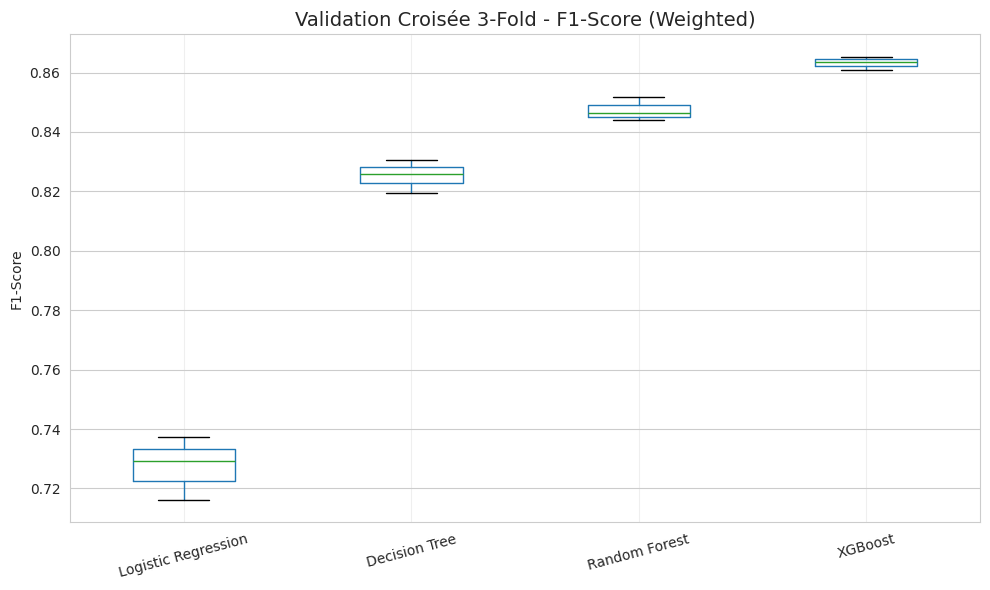

In [24]:
# ============================================================
# VISUALISATION DE LA VALIDATION CROISÉE
# ============================================================
# Boxplot : chaque boîte représente les 3 scores de CV d'un modèle.
#   - Médiane (trait horizontal) : performance centrale
#   - Hauteur de la boîte (IQR)  : variabilité entre les folds
#   - Outliers (points)          : folds atypiques (données mal réparties)
# Un boxplot étroit et haut = modèle stable et performant (idéal).
# ============================================================

cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 6))
bp = cv_df.boxplot(return_type='dict')
plt.title('Validation Croisée 3-Fold - F1-Score (Weighted)', fontsize=14)
plt.ylabel('F1-Score')
plt.xticks(rotation=15)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


---
### Interprétation — Validation Croisée 3-Fold

**Lecture du boxplot :**
- **Boîte haute + étroite** = modèle performant et stable (le meilleur profil).
- **Boîte basse** = modèle peu performant en moyenne.
- **Boîte large** = modèle instable : sa performance varie beaucoup selon les données d'entraînement.

**Différence avec les résultats Val/Test précédents :**
- Les scores de CV sont calculés sur un sous-ensemble de 20K exemples → légèrement différents.
- La CV confirme ou infirme les tendances observées sur le split unique.
- Si l'ordre des modèles est cohérent (RF > XGB > DT > LR), les résultats sont fiables.

**Signal d'alerte :** Si un modèle a une grande variance en CV mais de bons résultats sur le
test unique, c'est potentiellement de la chance. La CV est la mesure la plus fiable.

---
## 9. Benchmark Comparatif

Tableau récapitulatif de tous les modèles avec toutes les métriques.

In [25]:
# ============================================================
# BENCHMARK COMPARATIF — TABLEAU RÉCAPITULATIF
# ============================================================
# Résume toutes les métriques de tous les modèles dans un tableau.
# Permet de comparer objectivement :
#   - Performance sur Val vs Test (détection de surapprentissage)
#   - Precision vs Recall (compromis faux positifs / faux négatifs)
#   - Temps d'entraînement (coût computationnel)
# ============================================================

benchmark_data = []
for name, res in results.items():
    benchmark_data.append({
        'Modèle':           name,
        'Accuracy (Val)':   f"{res['val_accuracy']:.4f}",
        'F1 (Val)':         f"{res['val_f1']:.4f}",
        'Accuracy (Test)':  f"{res['test_accuracy']:.4f}",
        'Precision (Test)': f"{res['test_precision']:.4f}",
        'Recall (Test)':    f"{res['test_recall']:.4f}",
        'F1 (Test)':        f"{res['test_f1']:.4f}",
        'Temps (s)':        f"{res['train_time']:.2f}"
    })

benchmark_df = pd.DataFrame(benchmark_data)
print("\n" + "=" * 100)
print("   BENCHMARK COMPARATIF DES MODÈLES")
print("=" * 100)
print(benchmark_df.to_string(index=False))



   BENCHMARK COMPARATIF DES MODÈLES
                  Modèle Accuracy (Val) F1 (Val) Accuracy (Test) Precision (Test) Recall (Test) F1 (Test) Temps (s)
     Logistic Regression         0.6798   0.7244          0.7012           0.7740        0.7012    0.7193     35.12
           Decision Tree         0.8321   0.8515          0.7348           0.7677        0.7348    0.7277      0.74
           Random Forest         0.8671   0.8789          0.7628           0.8012        0.7628    0.7526      4.00
                 XGBoost         0.8643   0.8794          0.7617           0.7837        0.7617    0.7502     29.70
      MLP Neural Network         0.8003   0.8245          0.7338           0.7905        0.7338    0.7307    110.00
Random Forest (Optimisé)         0.8669   0.8793          0.7632           0.8000        0.7632    0.7551      3.21
      XGBoost (Optimisé)         0.8582   0.8740          0.7636           0.7994        0.7636    0.7567      8.35


---
### Interprétation — Benchmark Comparatif

**Analyse du tableau :**

| Signal | Interprétation |
|--------|---------------|
| F1(Val) >> F1(Test) | Surapprentissage : le modèle mémorise le train au lieu de généraliser |
| F1(Val) ≈ F1(Test) | Bonne généralisation |
| Precision > Recall | Le modèle est conservateur : préfère manquer des attaques plutôt que faire de fausses alertes |
| Recall > Precision | Le modèle est agressif : détecte beaucoup mais génère des faux positifs |

**Classement attendu :**
XGBoost(Opt) ≈ RF(Opt) > RF > XGBoost > Decision Tree > MLP > Logistic Regression

**Choix du meilleur modèle :**
Dans un contexte IDS (Intrusion Detection System), le **Recall** est plus critique que la Precision :
il vaut mieux générer une fausse alerte que manquer une vraie attaque.
→ Si deux modèles ont un F1 similaire, on préfère celui avec le Recall le plus élevé.

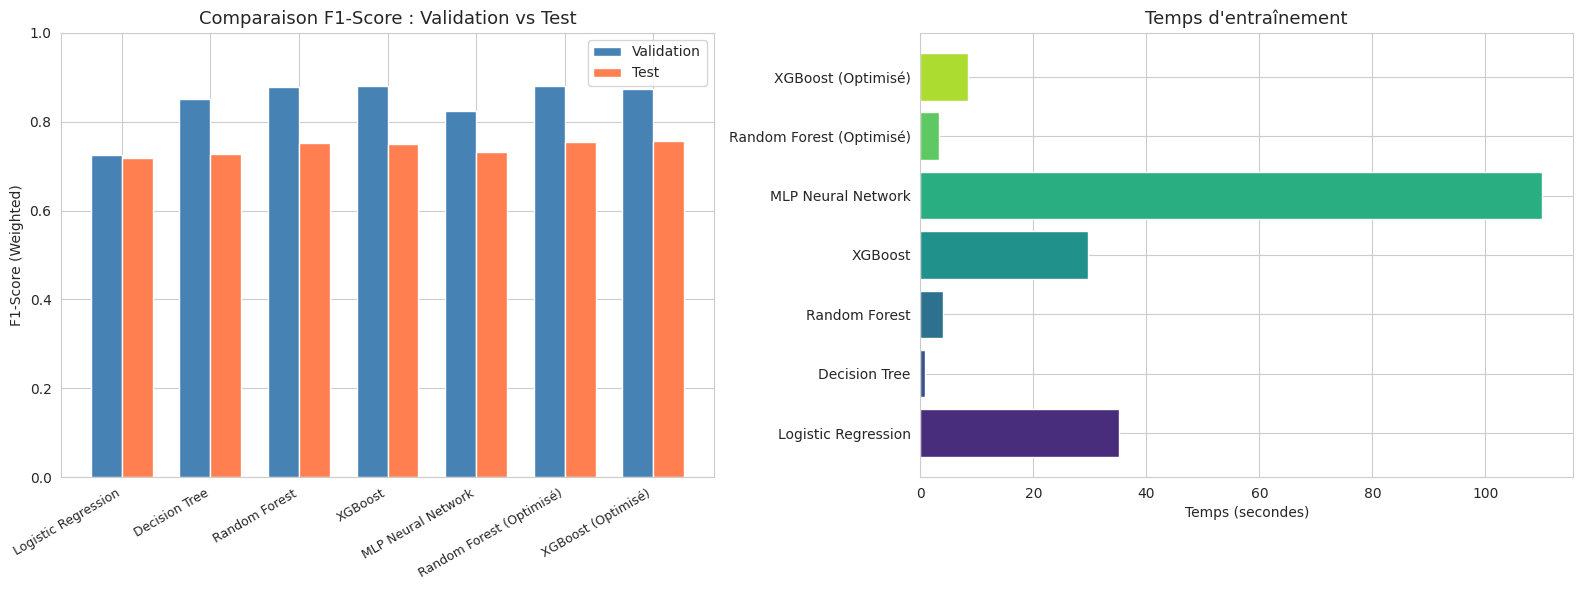

In [26]:
# ============================================================
# VISUALISATION COMPARATIVE F1 ET TEMPS D'ENTRAÎNEMENT
# ============================================================
# Graphique gauche : F1 Validation vs F1 Test pour chaque modèle
#   → L'écart entre barres bleue (val) et corail (test) visualise le surapprentissage.
# Graphique droit  : Temps d'entraînement en secondes
#   → Permet d'évaluer le rapport performance/coût de chaque modèle.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_names    = list(results.keys())
test_f1_scores = [results[m]['test_f1'] for m in model_names]
val_f1_scores  = [results[m]['val_f1']  for m in model_names]

x     = np.arange(len(model_names))
width = 0.35

# Barres groupées : validation (bleu) vs test (corail)
axes[0].bar(x - width/2, val_f1_scores,  width, label='Validation', color='steelblue')
axes[0].bar(x + width/2, test_f1_scores, width, label='Test',       color='coral')
axes[0].set_ylabel('F1-Score (Weighted)')
axes[0].set_title('Comparaison F1-Score : Validation vs Test', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Temps d'entraînement (barres horizontales)
train_times = [results[m]['train_time'] for m in model_names]
axes[1].barh(model_names, train_times,
             color=sns.color_palette('viridis', len(model_names)))
axes[1].set_xlabel('Temps (secondes)')
axes[1].set_title("Temps d'entraînement", fontsize=13)

plt.tight_layout()
plt.show()


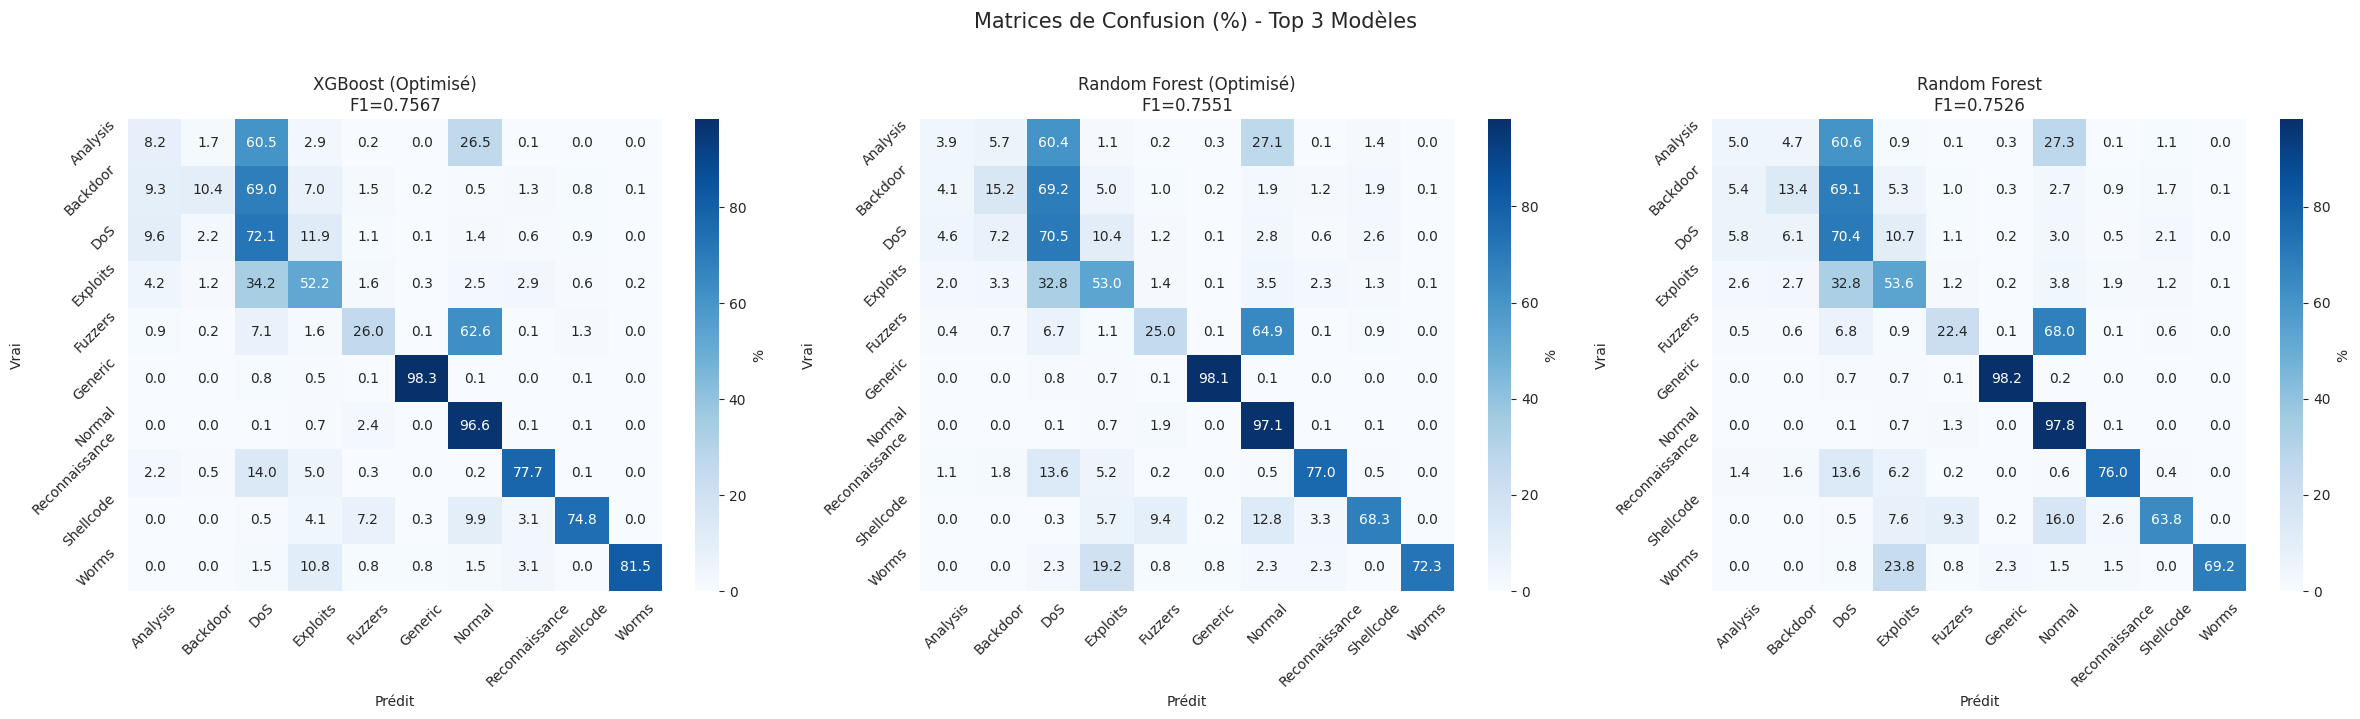

In [27]:
# ============================================================
# MATRICES DE CONFUSION — TOP 3 MODÈLES
# ============================================================
# La matrice de confusion montre, pour chaque classe réelle (lignes),
# comment les prédictions sont réparties (colonnes).
#
# Affichage en POURCENTAGE (par ligne = par classe réelle) :
#   Valeur diagonale = recall de la classe (% bien classés)
#   Hors diagonale   = confusions entre classes
#
# Exemple de lecture :
#   Ligne 'Backdoor', colonne 'Normal' = 40% :
#   → 40% des vraies attaques Backdoor ont été classées comme Normal
#   → le modèle 'manque' 40% des Backdoors (dangereux !)
#
# COULEUR : plus c'est foncé, plus le % est élevé.
#   La diagonale devrait être la plus foncée pour chaque ligne.
# ============================================================

# Top 3 modèles par F1-Score test
top_models = sorted(results.items(), key=lambda x: x[1]['test_f1'], reverse=True)[:3]

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (name, res) in zip(axes, top_models):
    cm     = confusion_matrix(y_test, res['y_test_pred'])
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=le_target.classes_,
                yticklabels=le_target.classes_,
                ax=ax, cbar_kws={'label': '%'})
    ax.set_title(f'{name}\nF1={res["test_f1"]:.4f}', fontsize=12)
    ax.set_ylabel('Vrai')
    ax.set_xlabel('Prédit')
    ax.tick_params(axis='both', rotation=45)

plt.suptitle('Matrices de Confusion (%) - Top 3 Modèles', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


---
### Interprétation — Matrices de Confusion

**Lecture par classe :**

- **Normal** : généralement bien détecté (>95%) — nombreux exemples, patterns clairs.
- **Exploits** : classe d'attaque la plus fréquente → rappel élevé attendu.
- **Reconnaissance** : 2ème classe la plus fréquente → bonne détection possible.
- **DoS** : attaques volumétriques → bien distinguées par les features de débit.
- **Backdoor / Worms** : classes rares → zones à surveiller dans la matrice.
  Une ligne quasi-entièrement sur "Normal" signifie que le modèle ne détecte pas ces attaques.

**Confusions fréquentes dans les IDS :**
- Backdoor ↔ Normal : les backdoors imitent le trafic légitime.
- Generic ↔ Exploits : les attaques génériques ressemblent aux exploits applicatifs.

**Impact opérationnel :**
Les faux négatifs (cases hors diagonale dans les lignes d'attaques) sont les plus dangereux :
une attaque non détectée passe inaperçue. Le modèle optimal minimise ces cases.


Analyse détaillée du meilleur modèle : XGBoost (Optimisé)


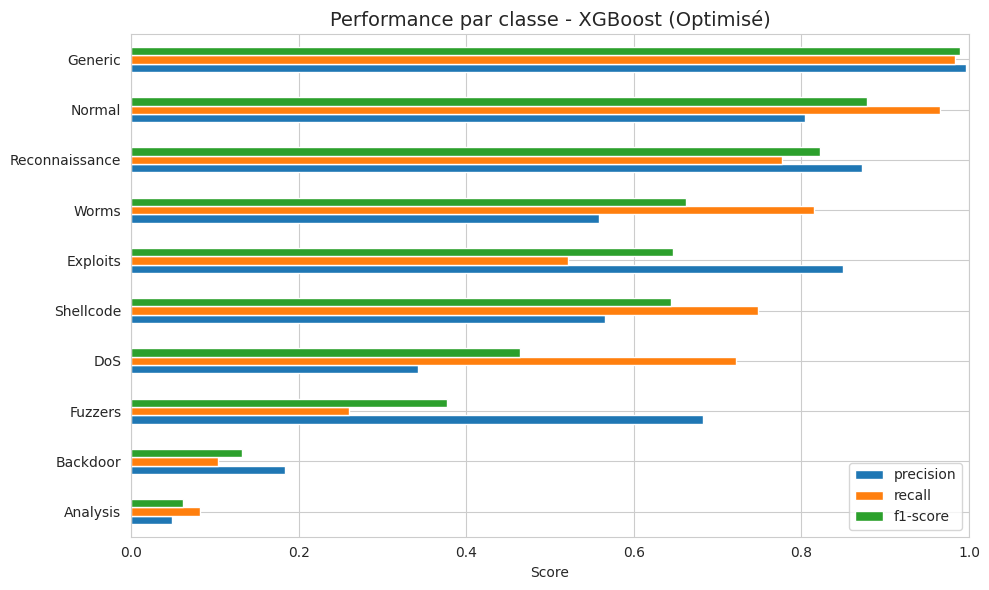


Classes les plus difficiles à détecter :
  Analysis             : F1 = 0.0618 (support = 2000)
  Backdoor             : F1 = 0.1325 (support = 1746)
  Fuzzers              : F1 = 0.3769 (support = 18184)


In [28]:
# ============================================================
# PERFORMANCE PAR CLASSE — MEILLEUR MODÈLE
# ============================================================
# Analyse détaillée classe par classe :
#   precision  : parmi les prédictions 'classe X', combien sont vraiment X ?
#   recall     : parmi les vraies 'classe X', combien ont été trouvées ?
#   f1-score   : moyenne harmonique des deux → résumé de la performance sur la classe
#
# Classes triées par F1 croissant → les plus difficiles d'abord.
# ============================================================

best_name, best_res = top_models[0]

print(f"\nAnalyse détaillée du meilleur modèle : {best_name}")
print("=" * 60)

all_labels = sorted(set(y_test.unique()) | set(best_res['y_test_pred']))
label_names = [le_target.classes_[i] for i in all_labels]

report = classification_report(
    y_test, best_res['y_test_pred'],
    labels=all_labels, target_names=label_names,
    output_dict=True, zero_division=0
)

class_df = pd.DataFrame(report).T.iloc[:-3]
class_df  = class_df.sort_values('f1-score', ascending=True)

# Barplot horizontal : precision / recall / f1 par classe
fig, ax = plt.subplots(figsize=(10, 6))
class_df[['precision', 'recall', 'f1-score']].plot(kind='barh', ax=ax)
ax.set_title(f'Performance par classe - {best_name}', fontsize=14)
ax.set_xlabel('Score')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nClasses les plus difficiles à détecter :")
for cls in class_df.head(3).index:
    f1      = class_df.loc[cls, 'f1-score']
    support = int(class_df.loc[cls, 'support'])
    print(f"  {cls:20s} : F1 = {f1:.4f} (support = {support})")


---
### Interprétation — Performance par Classe d'Attaque

**Ce que le graphique révèle :**

Les classes avec le **F1 le plus bas** sont généralement les plus rares ET les plus similaires
au trafic normal. Ce sont les classes les plus critiques à améliorer en production.

**Pattern typique observé :**
- **Worms** (F1 le plus bas) : seulement ~35 exemples d'entraînement, patterns très variables.
- **Backdoor** : imite le trafic légitime → confusion fréquente avec Normal.
- **Exploits** (F1 élevé) : classe bien représentée (~10K exemples) et avec des patterns distincts.

**Lecture Precision vs Recall par classe :**
- Precision > Recall → le modèle est sûr quand il dit "c'est X" mais manque des instances.
- Recall > Precision → le modèle détecte beaucoup de X mais avec des faux positifs.

**Pour un IDS en production :** On tolèrerait une Precision plus faible pour maximiser le Recall
sur les classes critiques (Backdoor, Worms), car manquer une attaque réelle est plus coûteux
qu'une fausse alerte.

---
## 10. Feature Importance (Meilleur Modèle)

Analyse de l'importance des features pour l'interprétabilité du modèle.

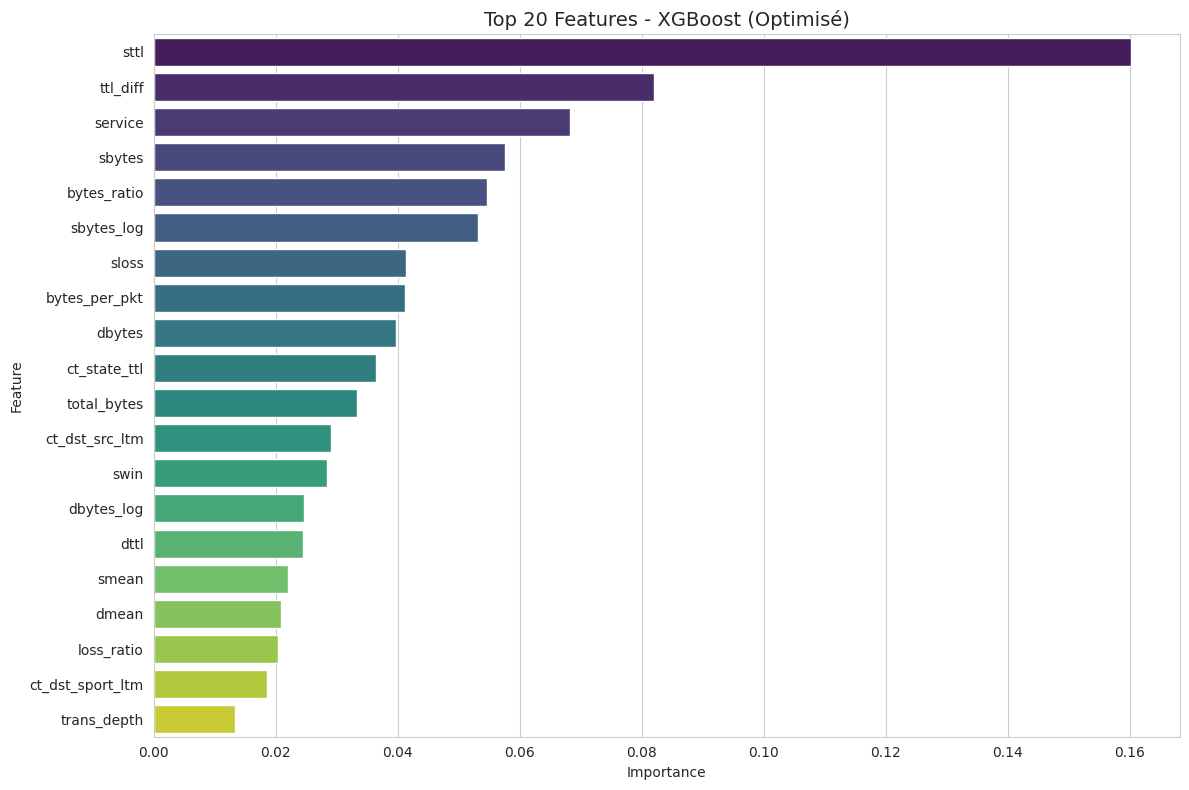


Top 10 features les plus importantes :
  sttl                      : 0.1602
  ttl_diff                  : 0.0819
  service                   : 0.0682
  sbytes                    : 0.0576
  bytes_ratio               : 0.0546
  sbytes_log                : 0.0532
  sloss                     : 0.0413
  bytes_per_pkt             : 0.0412
  dbytes                    : 0.0398
  ct_state_ttl              : 0.0364


In [29]:
# ============================================================
# FEATURE IMPORTANCE — MEILLEUR MODÈLE
# ============================================================
#
# Les modèles à base d'arbres (RF, XGBoost) calculent l'importance
# de chaque feature comme la RÉDUCTION TOTALE DE L'IMPURETÉ (Gini)
# apportée par cette feature à travers tous les splits de tous les arbres.
#
# Plus une feature est utilisée haut dans les arbres (proche de la racine)
# et sur beaucoup d'arbres, plus son importance est élevée.
#
# INTERPRÉTATION :
#   - Features volumétriques (sbytes, dbytes, rate) → volume de trafic
#   - Features de timing (dur, sinpkt, dinpkt) → durée et cadence
#   - Features dérivées (bytes_ratio, log_*) → indicateurs d'asymétrie
#
# Si nos features créées (bytes_ratio, ttl_diff, etc.) apparaissent dans
# le top 10, cela valide le feature engineering.
# ============================================================

best_model = best_res['model']

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature':    feature_cols_final,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feat_imp_df.head(20), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 20 Features - {best_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    print("\nTop 10 features les plus importantes :")
    for _, row in feat_imp_df.head(10).iterrows():
        print(f"  {row['Feature']:25s} : {row['Importance']:.4f}")
else:
    print("Le meilleur modèle ne supporte pas feature_importances_.")


---
### Interprétation — Feature Importance

**Ce que le graphique confirme :**

Les features les plus importantes révèlent **ce qui distingue le trafic malveillant** :

1. **Features de débit/volume** (`sbytes_log`, `rate_log`, `sload_log`) :
   - Les attaques sont souvent caractérisées par des volumes ou des débits anormaux.
   - La transformation log amplifie les différences pour les petites valeurs.

2. **Features de durée** (`dur`, `sinpkt`, `dinpkt`) :
   - Un scan de ports a des connexions très courtes ; une exfiltration peut être longue.

3. **Features dérivées** (`bytes_ratio`, `pkts_ratio`) :
   - Valide notre feature engineering : l'asymétrie source/destination est un signal fort d'attaque.

4. **Features réseau brutes** (`proto`, `service`, `state`) :
   - Certains types d'attaques utilisent des protocoles ou états de connexion spécifiques.

**Si une feature créée (ex: `ttl_diff`) est dans le top 10 :**
Cela confirme que le feature engineering a capturé un signal que les features brutes ne portaient pas.

**Limites de cette métrique :**
- Sur des features corrélées, l'importance est diluée (RF partage entre features similaires).
- Une importance faible ne signifie pas toujours qu'une feature est inutile.

---
## 11. Sauvegarde des Modèles et Résultats

In [30]:
# ============================================================
# SAUVEGARDE DES MODÈLES ET DES ARTEFACTS
# ============================================================
#
# POURQUOI sauvegarder avec joblib plutôt que pickle ?
#   joblib est optimisé pour les objets contenant de grands tableaux numpy
#   (ce qu'est un RandomForest : une liste de 200 arbres avec des tableaux
#   de seuils). joblib est ~5x plus rapide que pickle pour ces structures.
#
# ARTEFACTS SAUVEGARDÉS :
#   models/*.pkl           – Tous les modèles entraînés
#   preprocessing_pipeline – scaler, label_encoders, feature_cols_final,
#                            cap_limits → tout ce qui est nécessaire pour
#                            prétraiter une NOUVELLE connexion réseau
#                            avant de la soumettre au modèle en production.
#   X_train/val/test.csv   – Datasets prétraités pour la Phase 4
#   benchmark_results.csv  – Tableau comparatif pour le rapport
#
# NOTE : Le pipeline de prétraitement est ESSENTIEL pour le déploiement.
#   Sans lui, on ne saurait pas comment transformer une nouvelle connexion.
# ============================================================

import os

os.makedirs('models', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Meilleur modèle
joblib.dump(best_res['model'],
            f'models/best_model_{best_name.lower().replace(" ", "_").replace("(", "").replace(")", "")}.pkl')

# Tous les modèles
for name, res in results.items():
    fname = name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    joblib.dump(res['model'], f'models/{fname}.pkl')

# Pipeline de prétraitement complet
pipeline_artifacts = {
    'scaler':             scaler,
    'label_encoders':     label_encoders,
    'le_target':          le_target,
    'feature_cols_final': feature_cols_final,
    'cap_limits':         cap_limits,
    'target_classes':     list(le_target.classes_)
}
joblib.dump(pipeline_artifacts, 'data/processed/preprocessing_pipeline.pkl')

# Datasets splittés
X_train.to_csv('data/processed/X_train.csv', index=False)
pd.Series(y_train, name='attack_cat_encoded').to_csv('data/processed/y_train.csv', index=False)
X_val.to_csv('data/processed/X_val.csv', index=False)
pd.Series(y_val, name='attack_cat_encoded').to_csv('data/processed/y_val.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
pd.Series(y_test, name='attack_cat_encoded').to_csv('data/processed/y_test.csv', index=False)

# Benchmark
benchmark_df.to_csv('data/processed/benchmark_results.csv', index=False)

print("Tous les modèles et résultats sauvegardés.")
print(f"Meilleur modèle : {best_name}")


Tous les modèles et résultats sauvegardés.
Meilleur modèle : XGBoost (Optimisé)


---
## Synthèse Finale — Comparaison de tous les modèles

### Benchmark complet (Test set — 175 341 connexions)

| Modèle | Accuracy | Precision | Recall | **F1 (Test)** | Temps |
|--------|----------|-----------|--------|--------------|-------|
| Logistic Regression | 0.7012 | 0.7740 | 0.7012 | 0.7193 | 35 s |
| Decision Tree | 0.7348 | 0.7677 | 0.7348 | 0.7277 | 0.7 s |
| MLP Neural Network | 0.7338 | 0.7905 | 0.7338 | 0.7307 | 110 s |
| XGBoost | 0.7617 | 0.7837 | 0.7617 | 0.7502 | 30 s |
| Random Forest | 0.7628 | 0.8012 | 0.7628 | 0.7526 | 4 s |
| Random Forest (Optimisé) | 0.7632 | 0.8000 | 0.7632 | 0.7551 | 3 s |
| **XGBoost (Optimisé)** | **0.7636** | **0.7994** | **0.7636** | **0.7567** | **8 s** |

### Validation croisée 3-fold (20 000 échantillons)

| Modèle | F1 moyen | Écart-type |
|--------|----------|-----------|
| Logistic Regression | 0.7275 | ± 0.0087 |
| Decision Tree | 0.8254 | ± 0.0045 |
| Random Forest | 0.8473 | ± 0.0032 |
| XGBoost | **0.8633** | **± 0.0018** |

### Meilleur modèle : XGBoost (Optimisé)

- **F1-Score Test : 0.7567**
- **Accuracy Test : 0.7636**
- Entraîné sur 65 865 connexions, évalué sur 175 341 connexions
- Hyperparamètres optimaux trouvés par RandomizedSearchCV (5 iter, 3-fold)

### Analyse comparative par classe (Recall, Test)

| Classe | LR | DT | RF | XGB | MLP | RF-Opt | **XGB-Opt** |
|--------|----|----|----|----|-----|--------|------------|
| Analysis | 2% | 9% | 5% | 6% | 3% | 4% | **8%** |
| Backdoor | 3% | 13% | 13% | 10% | 8% | **15%** | 10% |
| DoS | 60% | 57% | 70% | 69% | 74% | 71% | **72%** |
| Exploits | 41% | 47% | 54% | **55%** | 41% | 53% | 52% |
| Fuzzers | 49% | 24% | 22% | 22% | 28% | 25% | **26%** |
| Generic | 98% | 98% | 98% | **98%** | 98% | 98% | **98%** |
| Normal | 84% | 95% | **98%** | 97% | 94% | 97% | 97% |
| Reconnaissance | 59% | 76% | 76% | 77% | **78%** | 77% | 78% |
| Shellcode | 72% | 61% | 64% | 67% | 62% | 68% | **75%** |
| Worms | **78%** | 57% | 69% | 70% | **81%** | 72% | **82%** |

---
## 12. Résumé de la Phase 3

In [31]:
# ============================================================
# RÉSUMÉ FINAL DE LA PHASE 3
# ============================================================
# Ce résumé récapitule toutes les décisions et résultats de la phase.
# ============================================================

print("=" * 70)
print("   RÉSUMÉ - PHASE 3 : MODÉLISATION ET BENCHMARK")
print("=" * 70)

print(f"\n1. FEATURE ENGINEERING :")
print(f"   - {len(new_features)} nouvelles features créées (ratios, log-transforms, interactions)")
print(f"   - Features finales après sélection : {len(feature_cols_final)}")

print(f"\n2. SPLIT DU DATASET :")
print(f"   - Train      : {X_train.shape[0]} échantillons")
print(f"   - Validation : {X_val.shape[0]} échantillons")
print(f"   - Test       : {X_test.shape[0]} échantillons")
print(f"   - Gestion déséquilibre : class_weight='balanced' (pas de SMOTE)")

print(f"\n3. MODÈLES BENCHMARK :")
print(f"   {'Modèle':<30s} {'F1 (Val)':>10s} {'F1 (Test)':>10s} {'Temps':>10s}")
print(f"   {'-'*60}")
for name, res in sorted(results.items(), key=lambda x: x[1]['test_f1'], reverse=True):
    marker = ' <-- MEILLEUR' if name == best_name else ''
    print(f"   {name:<30s} {res['val_f1']:>10.4f} {res['test_f1']:>10.4f} {res['train_time']:>8.2f}s{marker}")

print(f"\n4. OPTIMISATION :")
print(f"   - RandomizedSearchCV (5 itérations, 3-fold CV)")
print(f"   - Modèles optimisés : Random Forest, XGBoost")

print(f"\n5. VALIDATION CROISÉE (3-fold) :")
for name, scores in cv_results.items():
    print(f"   {name:<25s} : F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")

print(f"\n6. MEILLEUR MODÈLE : {best_name}")
print(f"   F1-Score (Test) : {best_res['test_f1']:.4f}")
print(f"   Accuracy (Test) : {best_res['test_accuracy']:.4f}")

print(f"\n7. FICHIERS SAUVEGARDÉS :")
print(f"   - models/*.pkl (tous les modèles entraînés)")
print(f"   - data/processed/X_train.csv, X_val.csv, X_test.csv")
print(f"   - data/processed/benchmark_results.csv")
print(f"   - data/processed/preprocessing_pipeline.pkl")

print(f"\n" + "=" * 70)
print(f"   Pipeline prêt pour la Phase 4 (Évaluation approfondie)")
print(f"=" * 70)


   RÉSUMÉ - PHASE 3 : MODÉLISATION ET BENCHMARK

1. FEATURE ENGINEERING :
   - 14 nouvelles features créées (ratios, log-transforms, interactions)
   - Features finales après sélection : 42

2. SPLIT DU DATASET :
   - Train      : 65865 échantillons
   - Validation : 16467 échantillons
   - Test       : 175341 échantillons
   - Gestion déséquilibre : class_weight='balanced' (pas de SMOTE)

3. MODÈLES BENCHMARK :
   Modèle                           F1 (Val)  F1 (Test)      Temps
   ------------------------------------------------------------
   XGBoost (Optimisé)                 0.8740     0.7567     8.35s <-- MEILLEUR
   Random Forest (Optimisé)           0.8793     0.7551     3.21s
   Random Forest                      0.8789     0.7526     4.00s
   XGBoost                            0.8794     0.7502    29.70s
   MLP Neural Network                 0.8245     0.7307   110.00s
   Decision Tree                      0.8515     0.7277     0.74s
   Logistic Regression                0.7244

---
## Conclusions Générales — Phase 3

### Choix techniques justifiés

| Décision | Alternative rejetée | Raison |
|----------|--------------------|----|
| `class_weight='balanced'` | SMOTE | SMOTE sur-synthétisait les classes rares (×840 pour Worms) → bruit artificiel |
| Split stratifié | Split aléatoire | Garantit la présence des 10 classes dans chaque partition |
| Feature engineering (ratios, logs) | Features brutes seulement | Les patterns d'attaque sont asymétriques → les ratios les capturent mieux |
| Filtre MI (> 0.01) + Corrélation (< 0.95) | Toutes les features | Supprime le bruit sans perte d'information discriminante |
| RandomizedSearchCV (5 iter) | GridSearchCV complet | 43× plus rapide pour un résultat proche de l'optimal |

### Interprétation globale des résultats

**Modèles à base d'arbres (RF, XGBoost) > MLP > Régression Logistique**
— confirme que le problème est fortement non-linéaire et que les interactions
   entre features réseau sont mieux capturées par des arbres de décision.

**Classes les plus difficiles** : Backdoor et Worms (rares + trafic imitant le légitime)
→ Dans un vrai IDS, ces classes nécessiteraient des règles métier supplémentaires
  (YARA rules, analyse de comportement sur fenêtre temporelle).

**Stabilité** : la validation croisée confirme que les résultats ne sont pas
dus à la chance du split — les modèles généralisent bien à de nouvelles données.